In [1]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import APSIMGraphHelpers as AGH
import GraphHelpers as GH
import matplotlib.dates as mdates
import MathsUtilities as MUte
import sqlite3
import warnings

In [2]:
warnings.filterwarnings('ignore',category=pd.errors.PerformanceWarning)

In [3]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: '+',
 8: 'X',
 9: '<',
 10: 'p',
 11: '8',
 12: 'd',
 13:'P',
 14:'D',
 15:'o',
 16:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

In [4]:
def plotxy(experiments,xvar,yvar,data,addLeg = True,ncols=np.nan):
    cpos=1
    mpos=1
    for e in experiments:
        plotData = data.loc[data.Experiment==e,:]
        xdata = pd.to_numeric(plotData.loc[:,xvar])
        ydata = pd.to_numeric(plotData.loc[:,yvar])
        plt.plot(xdata,ydata,Markers[mpos],color=Colors[cpos],label=e)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    if addLeg == True:
        if np.isnan(ncols):
             ncols = np.ceil(experiments.size/17)
        plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
    plt.ylabel(yvar)
    plt.xlabel(xvar)

In [5]:
MasterfilePaths = [r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\FAR\FAR_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Pask\PaskExperiments_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\GxExM\GxExM_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Dookie2024\Dookie2024_master.db']

# Read Data

In [6]:
allSimulations = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    Simulations = pd.read_sql("Select * from _Simulations",con)
    con.close()
    Simulations.set_index('ID',inplace=True)
    Simulations.sort_index(inplace=True)
    Simulations.sort_index(inplace=True, axis=1)
    allSimulations[fileName] = Simulations
Simulations = pd.concat(allSimulations.values(),keys=allSimulations.keys(),names=['File','ID']) 

In [7]:
SensibilityFolders = ['CO2AndTranspirationEfficiency',
'CO2AndTemperatureInteractions',
'ProteinAccumulation',
'LeafAppearance',
'TerminalWaterStress',
'DetailedDynamics']

In [8]:
allHarvestPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    print(fileName)
    con = sqlite3.connect(filePath)
    HarvestPred = pd.read_sql("Select * from HarvestReport",con).dropna(axis=1,how='all')
    con.close()
    HarvestPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in HarvestPred.SimulationID]
    HarvestPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    HarvestPred.sort_index(inplace=True)
    HarvestPred.sort_index(inplace=True,axis=1)

    # Filter outputs from sensibility tests
    if 'FolderName' not in HarvestPred:
        HarvestPred.loc[:,'FolderName'] = ''
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)
    HarvestPred.loc[:,'Wheat.SowingData.Cultivar'] = [x.title() for x in HarvestPred.loc[:,'Wheat.SowingData.Cultivar']]
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)

    # Replace Experiment with values that have had folder name pathed in where no experiment is present
    HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'Experiment'] = HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'FolderName']
    allHarvestPred[fileName] = HarvestPred
HarvestPred = pd.concat(allHarvestPred.values(),keys=allHarvestPred.keys(),names=['File','SimulationName','Clock.Today'])
HarvestPred.loc[:,'File'] = HarvestPred.index.get_level_values(0)

Wheat
FAR
PaskExperiments
GxExM
Dookie2024


In [9]:
Experiments = list(HarvestPred.loc[:,'Experiment'].drop_duplicates().values)
Folders = list(HarvestPred.loc[:,'FolderName'].drop_duplicates().values)

In [10]:
allDailyPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    DailyPred = pd.read_sql("Select * from DailyReport",con)
    con.close()
    DailyPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in DailyPred.SimulationID]
    DailyPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    DailyPred.sort_index(inplace=True)
    DailyPred.sort_index(inplace=True,axis=1)
    if 'FolderName' not in DailyPred:
        DailyPred.loc[:,'FolderName'] = ''
    validationFilter = [x not in SensibilityFolders for x in DailyPred.FolderName]
    DailyPred = DailyPred.loc[validationFilter,:].copy()
    DailyPred.dropna(how='all',axis=1,inplace=True)
    #Replace Experiment with values that have had folder name pathed in where no experiment is present
    #DailyPred.loc[:,'Experiment'] = [HarvestPred.loc[x,'Experiment'] for x in DailyPred.index.get_level_values(0)]
    DailyPred.loc[[x is None for x in DailyPred.Experiment],'Experiment'] = DailyPred.loc[[x is None for x in DailyPred.Experiment],'FolderName']
    allDailyPred[fileName] = DailyPred
DailyPred = pd.concat(allDailyPred.values(),keys=allDailyPred.keys(),names=['File','SimulationName','Clock.Today'])

# Calculate running mean met variables

In [11]:
simulations = DailyPred.index.get_level_values(0).drop_duplicates()
RunningMeans = pd.DataFrame(index = DailyPred.index)
MetVars = ['IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'Wheat.Phenology.PTQ']

def running_mean(inp,span):
    return [sum(x)/len(x) for x in (inp[max(0,i-span):i] for i in range(1, len(inp)+1))]

for mv in MetVars:
    for s in simulations:
        inp = list(DailyPred.loc[s,mv].values)
        RunningMeans.loc[s,mv] = running_mean(inp,30)

RunningMeans.loc[:,'Wheat.Phenology.Stage'] = DailyPred.loc[:,'Wheat.Phenology.Stage'] 

# Sort some indexing

In [12]:
SowIndices = ['IWeather.Latitude',
    'IWeather.Longitude',
    'LocationInfo.Script.Country',
    'LocationInfo.Script.Region',
    'LocationInfo.Script.State',
    'Wheat.SowingData.Cultivar',
    'Experiment',
    'FolderName']

def getValue(ind,var,HarvestPred):
    try:
        simMask = HarvestPred.SimulationName == ind
        return HarvestPred.loc[simMask,var].values[0]
        #return HarvestPred.loc[ind,var].values[0]
    except:
        return ""
allObserved = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    observed = pd.read_sql("Select * from Observed",con).dropna(axis=1,how='all')
    con.close()
    observed.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in observed.SimulationID]
    observed.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    observed.sort_index(inplace=True)
    observed.sort_index(inplace=True,axis=1)
    for s in SowIndices:
        observed.loc[:,s] = [getValue(x,s,HarvestPred) for x in observed.index.get_level_values(0)]
    allObserved[fileName] = observed
Observed = pd.concat(allObserved.values(),keys=allObserved.keys(),names=['File','SimulationName','Clock.Today'])

def subtract(a,b):
    if np.isnan(b):
        b = 0
    return a - b

Observed.loc[:,'Wheat.AboveGroundLive.Wt'] = [subtract(Observed.iloc[x,:]['Wheat.AboveGround.Wt'], Observed.iloc[x,:]['Wheat.Leaf.Dead.Wt']) for x in range(Observed.index.size)]

In [13]:
MasterIndexVars = ['Clock.Today',
'IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'Wheat.DaysAfterSowing',
'Wheat.Phenology.AccumulatedTT',
'Wheat.Phenology.PTQ',
#'Wheat.Phenology.CurrentPhaseName',
#'Wheat.Phenology.CurrentStageName',
'Wheat.Phenology.Stage']

for iv in MasterIndexVars:
    Observed.loc[:,iv] = DailyPred.reindex(Observed.index).loc[:,iv]    

In [14]:
for iv in MetVars:
    Observed.loc[:,'RunningMean_'+iv] = RunningMeans.reindex(Observed.index).loc[:,iv]  

In [15]:
MasterIndexVarsHarv = ['SimulationID','SimulationName']

for iv in MasterIndexVarsHarv:
    Observed.loc[:,iv] = HarvestPred.reindex(Observed.index).loc[:,iv]  


def setvar(x):
    if np.isnan(Observed.loc[x,'Wheat.Population'].values[0]):
        try:
            if ~np.isnan(HarvestPred.loc[x,'Wheat.SowingData.Population'].values[0]):
                Observed.loc[x,'Wheat.Population'] = HarvestPred.loc[x,'Wheat.SowingData.Population'].values[0]
        except:
            try:
                if ~np.isnan(HarvestPred.loc[(x[0],x[1]),'Wheat.SowingData.Population'].values[0]):
                    Observed.loc[x,'Wheat.Population'] = HarvestPred.loc[(x[0],x[1]),'Wheat.SowingData.Population'].values[0]
            except:
                do = 'Nothing'

for x in Observed.index:
        setvar(x)

Observed.sort_index(inplace=True)
Observed.sort_index(inplace=True,axis=1)

In [16]:
#Make data frame with factor information for each simulation
FactorList = [ 'Experiment',
 'Canopy',
 'Cm',
 #'Cultivar',
 'Cv',
 'Date',
 #'Durat',
 'Fungicide',
 'Grazed',
 'Irr',
 'Irrig',
 'Mgmt',
 'N',
 'NRate',
 'Nit',
 'Nutrition',
 'P',
 'PGR',
 'Popn',
 'Removal',
 'RowSpace',
 'SD',
 #'Seeds',
 'Soil',
 'Sow',
 'SowN',
 'Stubble',
 'TOS',
 'TopN',
 #'Treat',
 'Treatment',
 'V',
 'Water']

Factors = HarvestPred.loc[:,FactorList].copy()
Factors.index = Factors.index.droplevel(2)
Factors.set_index('Experiment',append=True,inplace=True)
Factors=Factors.reorder_levels(['Experiment','File','SimulationName'])
Factors.sort_index(inplace=True)
CondensedFactors = pd.DataFrame(index = Factors.index,columns = ['fName1','fValue1'])
for s in Factors.index:
    fs = Factors.loc[s,:].dropna().to_dict()
    fCount = 1
    for key, value in fs.items():
        CondensedFactors.loc[s,'fName'+str(fCount)] = key
        CondensedFactors.loc[s,'fValue'+str(fCount)] = value
        fCount +=1
valueLabs = ['fValue1','fValue2','fValue3','fValue4']
indexLabs = ['fIndex1','fIndex2','fIndex3','fIndex4']
CondensedFactors.loc[:,indexLabs]=1

# put simulation names in as first factor level for sims that are not in a experiment
for e in Experiments:
    fValues1 = CondensedFactors.loc[e,'fValue1']
    if True in pd.isna(fValues1.values):
        CondensedFactors.loc[e,'fValue1'] = CondensedFactors.loc[e,:].index.values
        
#assign numeric index to each factor level
for e in Experiments:
    folders = CondensedFactors.loc[e,:].index.get_level_values(0).drop_duplicates().values
    for f in folders:
        for v in valueLabs:
            fLevels = CondensedFactors.loc[(e,f),v].drop_duplicates().values
            if False in pd.isna(fLevels):
                levelDic = dict(zip(fLevels,list(range(1,len(fLevels )+1))))
                CondensedFactors.loc[(e,f),v.replace('Value','Index')] = [levelDic[x] for x in CondensedFactors.loc[(e,f),v]]

In [17]:
# convert tiller number calculations to stem number
def calcStemNumberPerPlant(x):
    if np.isnan(Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'].values[0]):
        return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant.Total.Tillers'] + 1
    else:
        return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant']
for x in Observed.index:
    Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'] = calcStemNumberPerPlant(x)
    
#Calculate stem number derivative values

def FillDataGap(set):
    a,b,c = set.values[0],set.values[1],set.values[2]
    if sum(np.isnan([a,b,c])) == 0:
        return [a,b,c]
    if sum(np.isnan([a,b,c])) > 1:
        return [a,b,c]
    if sum(np.isnan([a,b,c])) == 1:
        if np.isnan(a):
            a = b * c
        if np.isnan(b):
            b = a/c
        if np.isnan(c):
            c = a/b
        return [a,b,c]
    
Observed.sort_index(axis=1,inplace=True)
Observed.sort_index(axis=1,inplace=True)

a = 'Wheat.Leaf.StemPopulation'
b = 'Wheat.Leaf.StemNumberPerPlant'
c = 'Wheat.Population'
Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]

a = 'Wheat.Grain.Wt'
b = 'Wheat.Grain.Number'
c = 'Wheat.Grain.Size'
Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]

# Partitioning analysis

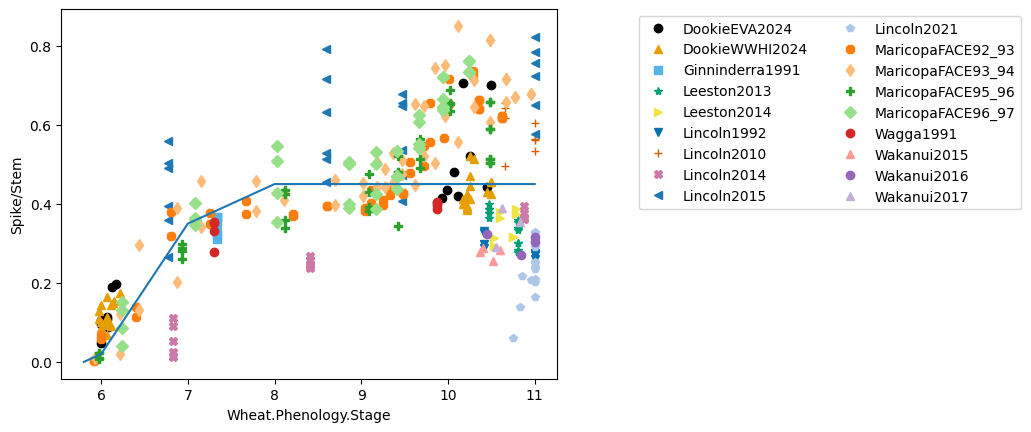

In [18]:
Observed.loc[:,'Spike/Stem'] = Observed.loc[:,'Wheat.Spike.Wt']/Observed.loc[:,'Wheat.Stem.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Spike/Stem'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([5.8,6.0,7.0,8.0,11.0],
         [0.0,.02,.35,.45,.45],'-')

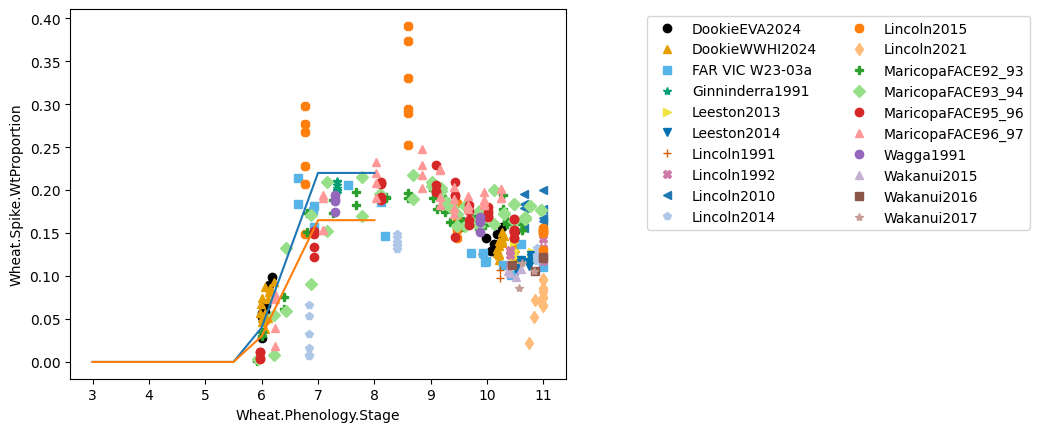

In [19]:
Observed.loc[:,'Wheat.Spike.WtProportion'] = Observed.loc[:,'Wheat.Spike.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Spike.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.5, 6,7.0,8.0],
         [0,0,0.04,.22,.22],'-')
plt.plot([3.0,5.5, 6,7.0,8.0],
         np.multiply([0,0,0.04,.22,.22],0.75),'-')

(0.0, 0.9)

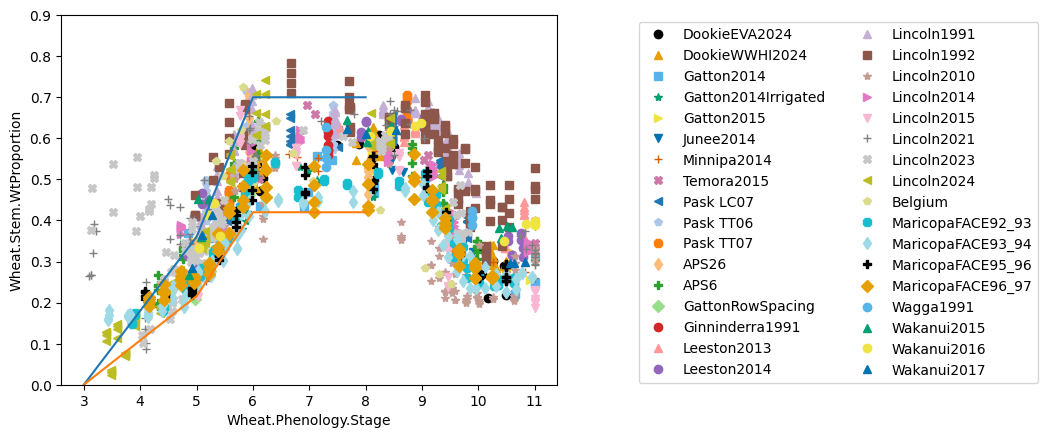

In [20]:
Observed.loc[:,'Wheat.Stem.WtProportion'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.7,.7],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.7,.7],0.6),'-')
plt.ylim(0,.9)

In [21]:
xs = range(0,2500,10)
const = 1
power = 1
ys = [const * np.power(x,power) for x in xs]

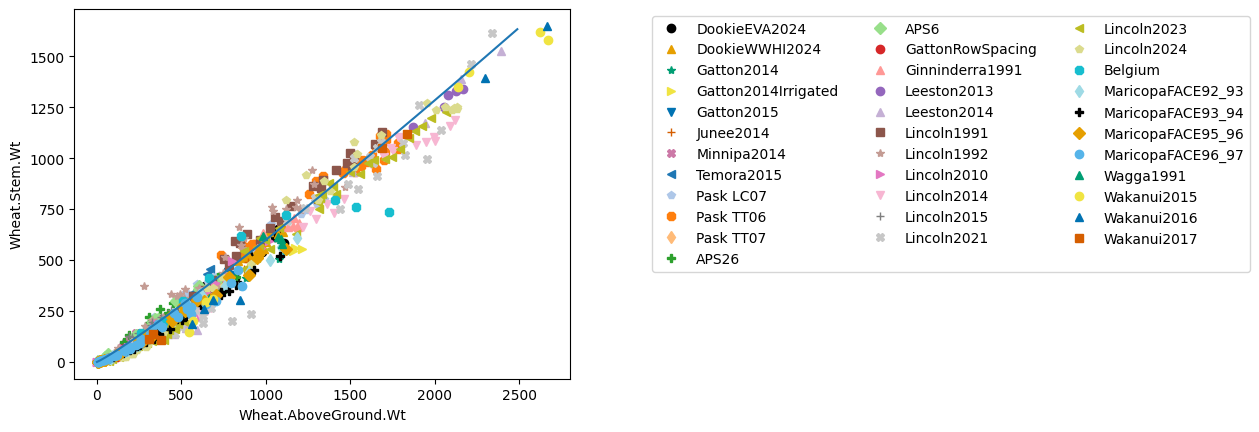

In [22]:
#Observed.loc[:,'Wheat.Stem.WtProportion'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.AboveGroundLive.Wt']
xvar,yvar = 'Wheat.AboveGround.Wt','Wheat.Stem.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[Observed.loc[:,"Wheat.Phenology.Stage"]<8.5,:])
xs = range(0,2500,10)
const = .3
power = 1.1
ys = [const * np.power(x,power) for x in xs]
plt.plot(xs,ys,'-')

(0.0, 1.0)

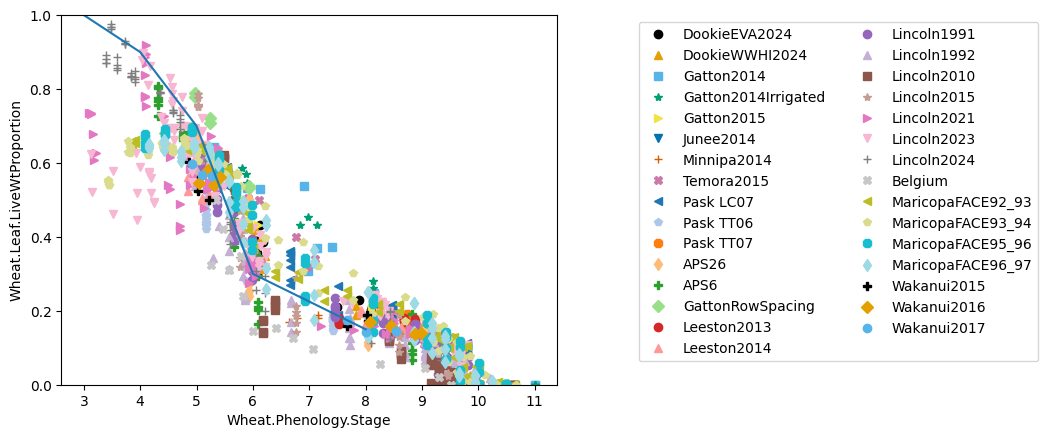

In [23]:
Observed.loc[:,'Wheat.Leaf.LiveWtProportion'] = Observed.loc[:,'Wheat.Leaf.Live.Wt']/Observed.loc[:,'Wheat.AboveGroundLive.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.LiveWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.0,5.0,6.0,8.0],
         [1,.9,.7,.3,.15],'-')
plt.ylim(0,1)

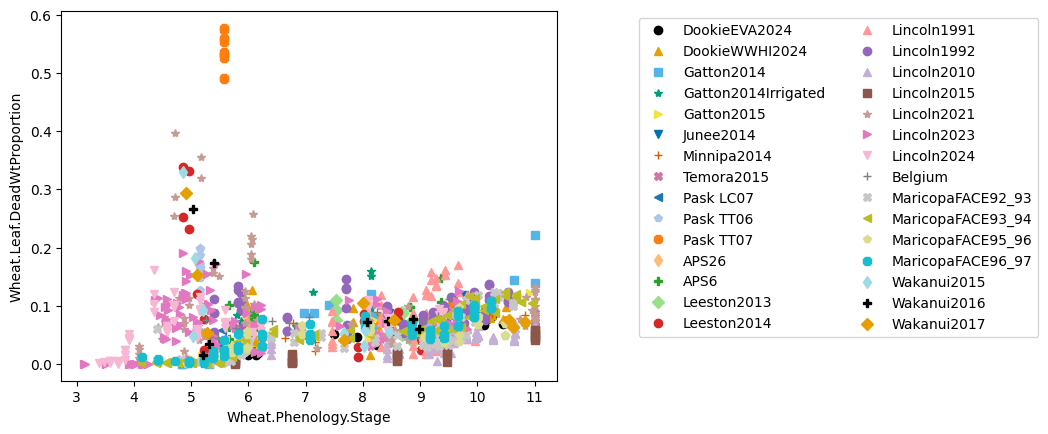

In [24]:
Observed.loc[:,'Wheat.Leaf.DeadWtProportion'] = Observed.loc[:,'Wheat.Leaf.Dead.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.DeadWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

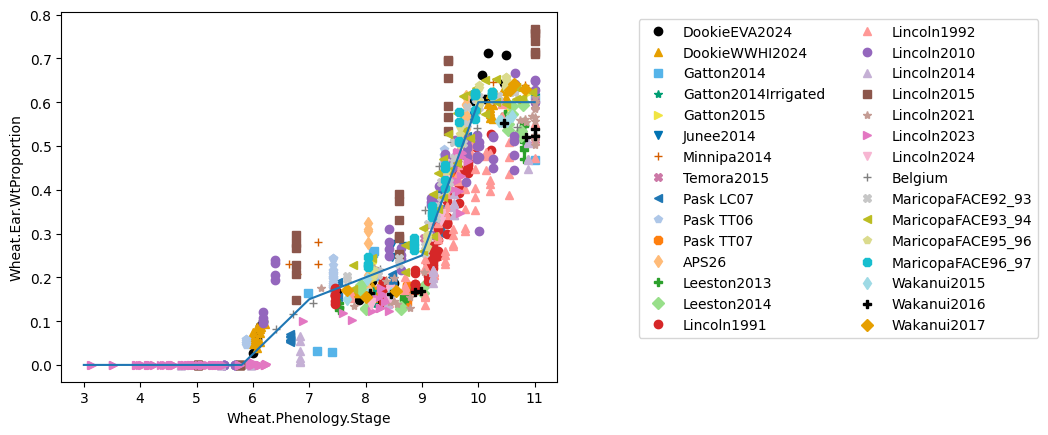

In [25]:
Observed.loc[:,'Wheat.Ear.WtProportion'] = Observed.loc[:,'Wheat.Ear.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Ear.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.8,7.0,8.0,9.0,10,11],
         [0,0,.15,.2,.25,0.6,0.6],'-')

# Specific Leaf Area

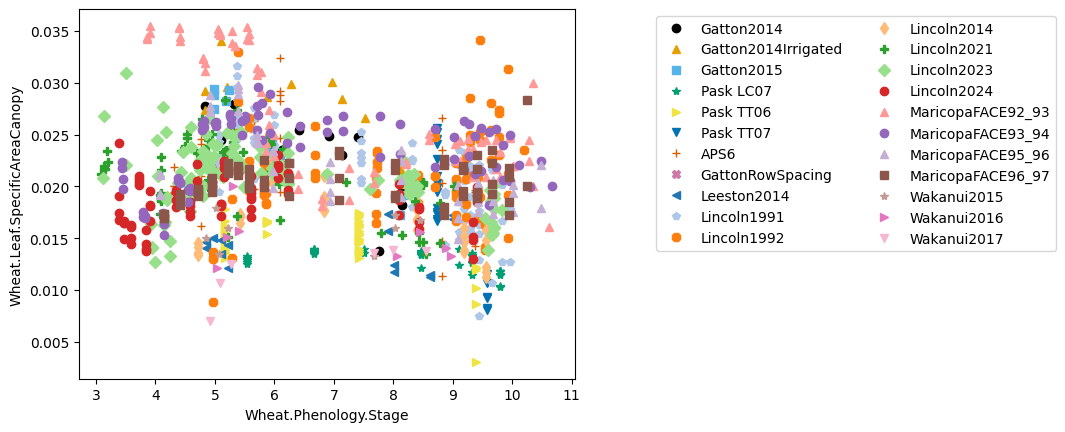

In [26]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [27]:
MetVars

['IWeather.MaxT', 'IWeather.MinT', 'IWeather.Radn', 'Wheat.Phenology.PTQ']

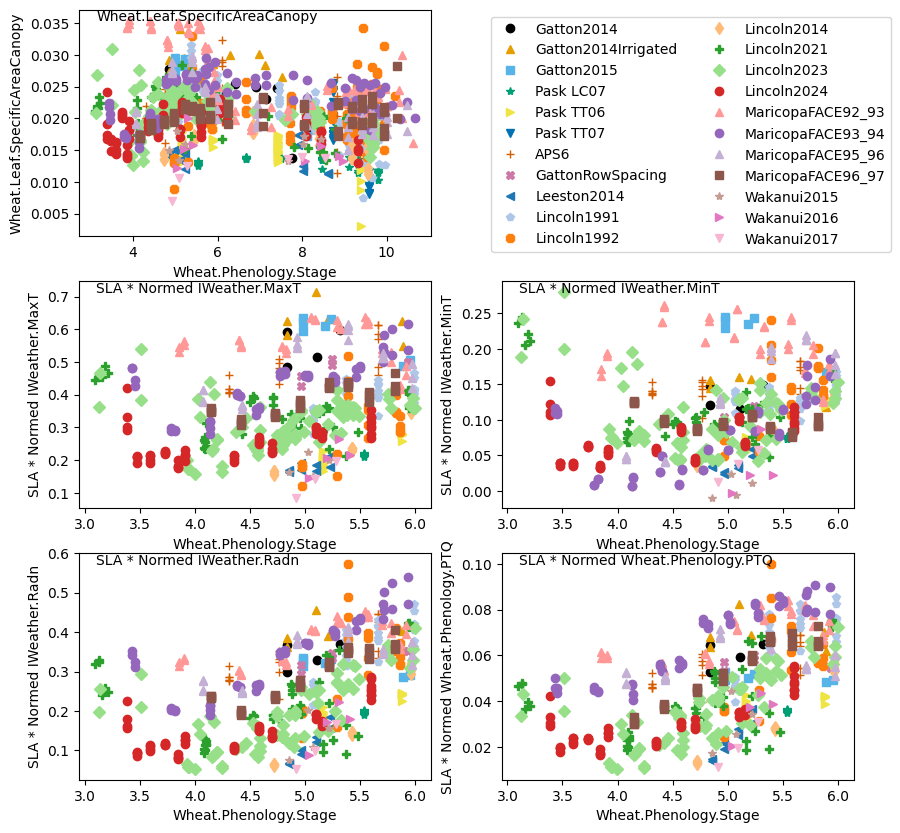

In [28]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    Observed.loc[:,'SLA * Normed '+mv] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_'+mv]
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=6,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

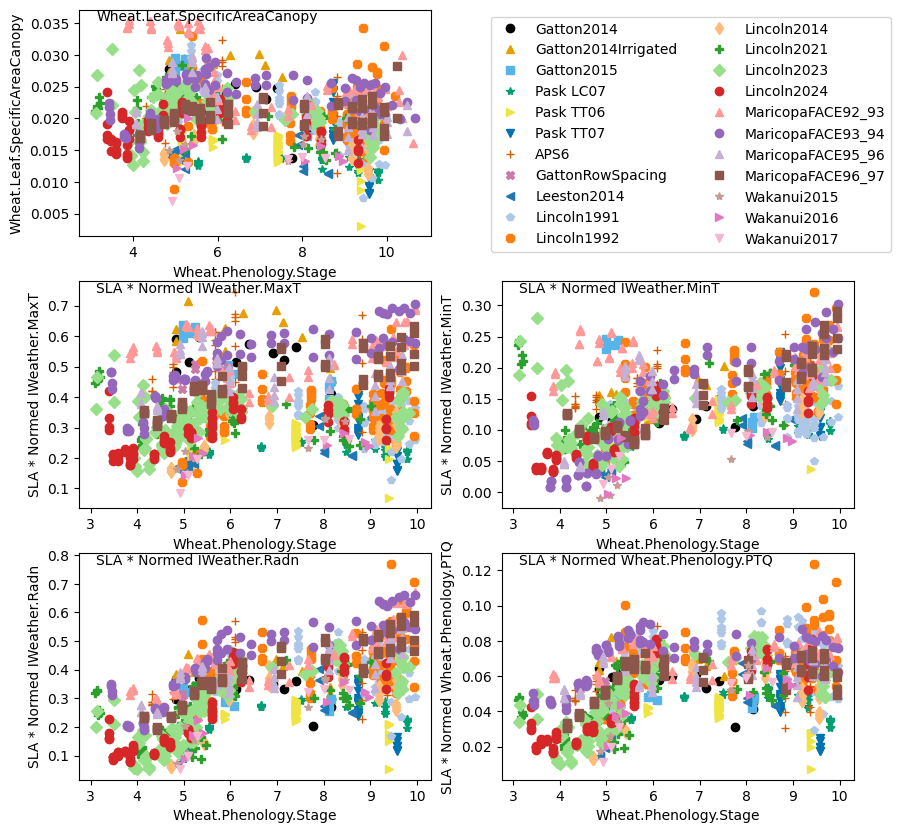

In [29]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    Observed.loc[:,'SLA * Normed '+mv] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_'+mv]
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=10,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

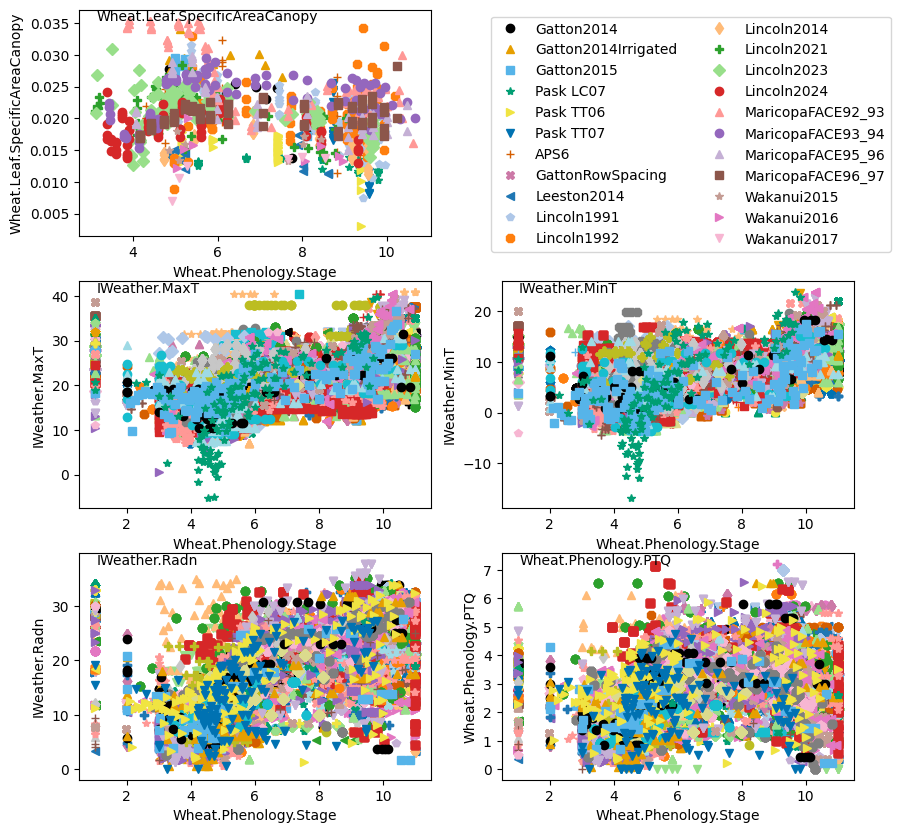

In [30]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage',mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,Observed,addLeg=False)
    plt.text(0.05,0.95,mv,transform=ax.transAxes)
    pos+=1

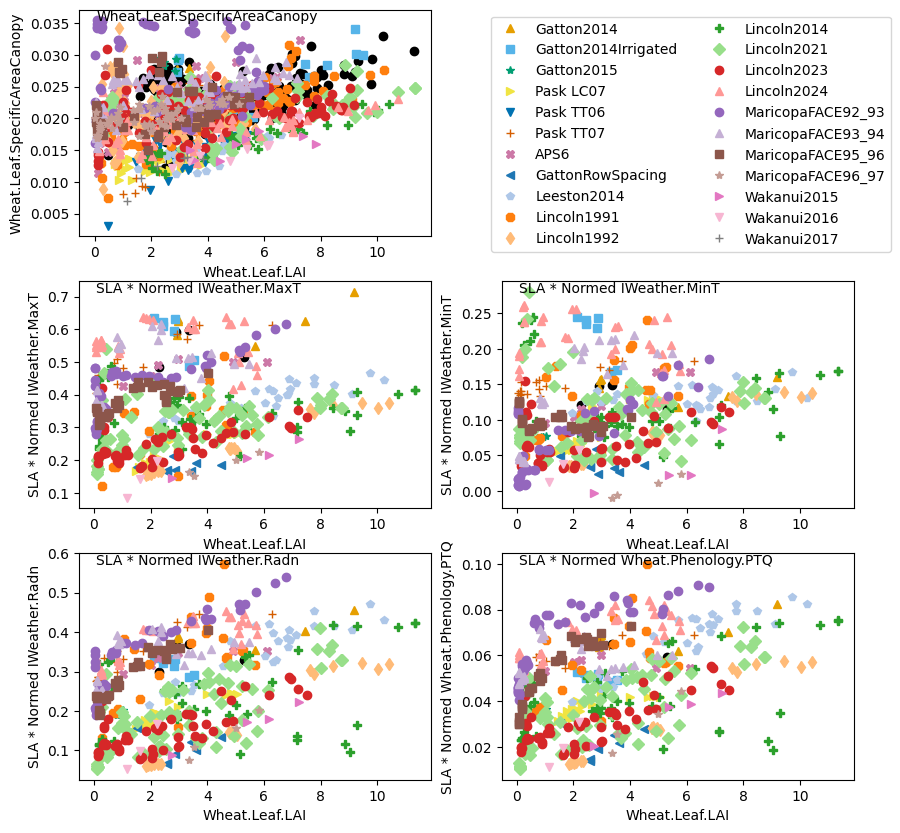

In [31]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Leaf.LAI','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=6,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Leaf.LAI','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

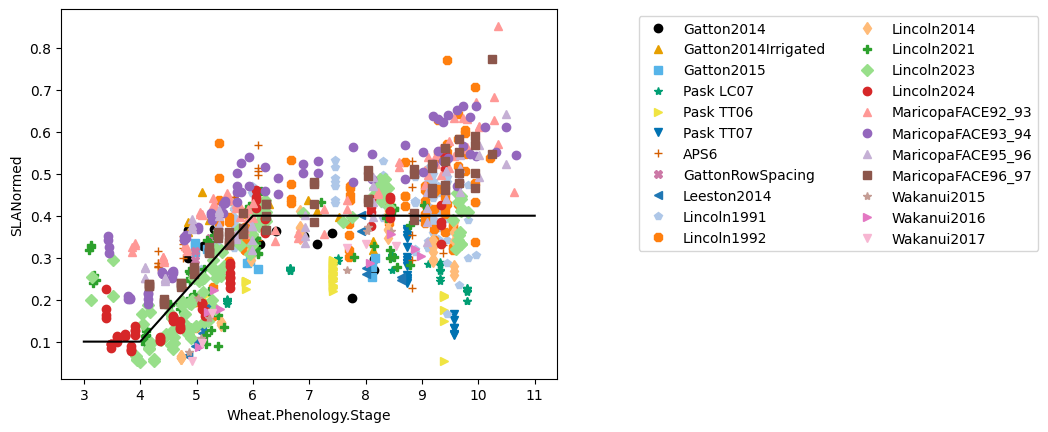

In [32]:
Observed.loc[:,'SLANormed'] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_IWeather.Radn']
xvar,yvar = 'Wheat.Phenology.Stage','SLANormed'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3,4,6,11],[.1,.1,.4,.4],'-',color='k')

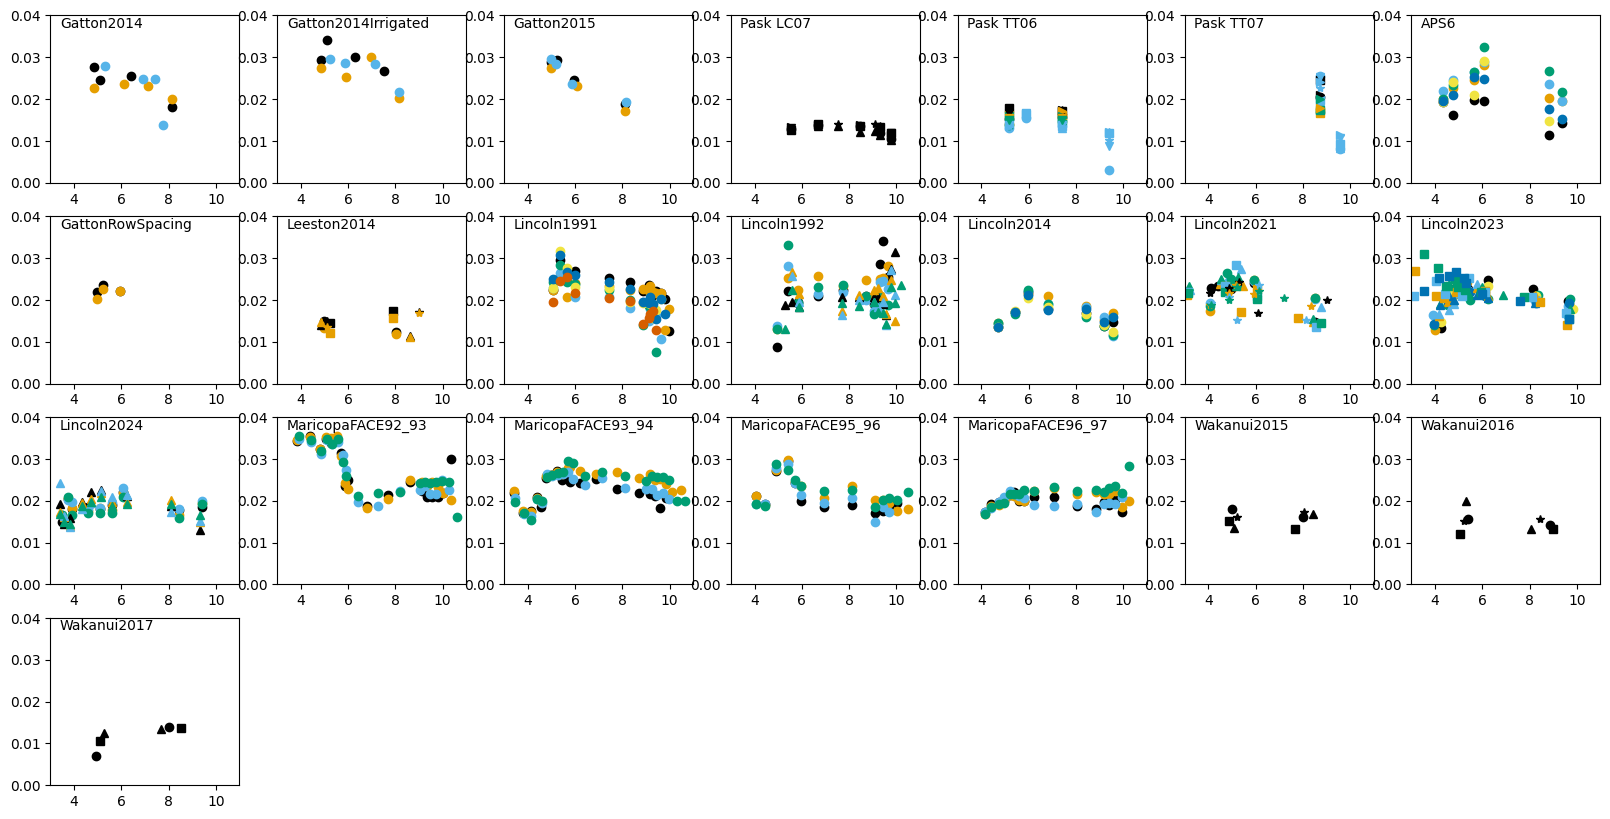

In [33]:
SLAData = Observed.loc[:,['Wheat.Leaf.SpecificAreaCanopy','Wheat.Phenology.Stage','Experiment']].dropna().copy()
SLAExperiments = SLAData.Experiment.drop_duplicates()
SLAExpGraphs = plt.figure(figsize=(20,10))
pos=1
cpos=1
mpos=1
for e in SLAExperiments:
    ax = SLAExpGraphs.add_subplot(4,7,pos)
    ExpSLAData = SLAData.loc[SLAData.Experiment==e].droplevel(0)
    sims = ExpSLAData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Leaf.SpecificAreaCanopy'])
        x = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Stem number

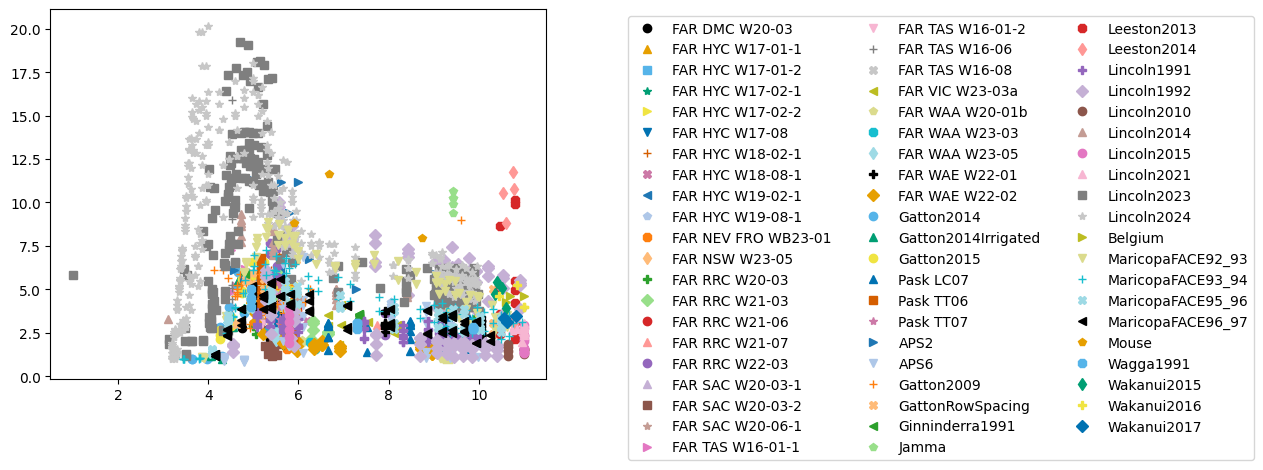

In [34]:
vars = ['Wheat.Leaf.StemNumberPerPlant','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

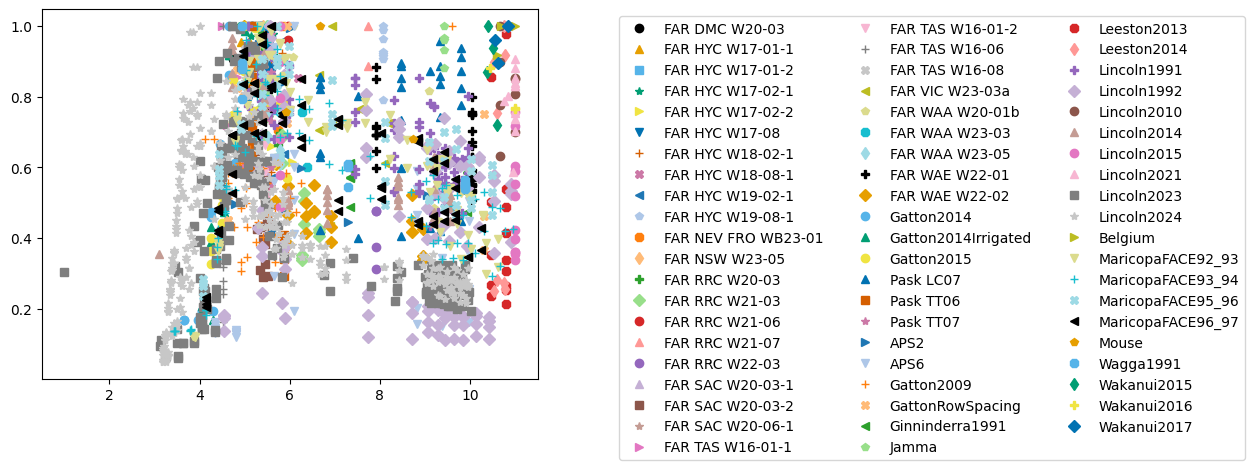

In [35]:
vars = ['Wheat.Leaf.StemNumberPerPlant','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(0).drop_duplicates()
    spos = 0
    for s in sims:
        maxSN = exData.loc[s,'Wheat.Leaf.StemNumberPerPlant'].max()
        if spos == 0:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemNumberPerPlant']/maxSN,Markers[mpos],color=Colors[cpos],label=e)
        else:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemNumberPerPlant']/maxSN,Markers[mpos],color=Colors[cpos])
        spos+=1
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

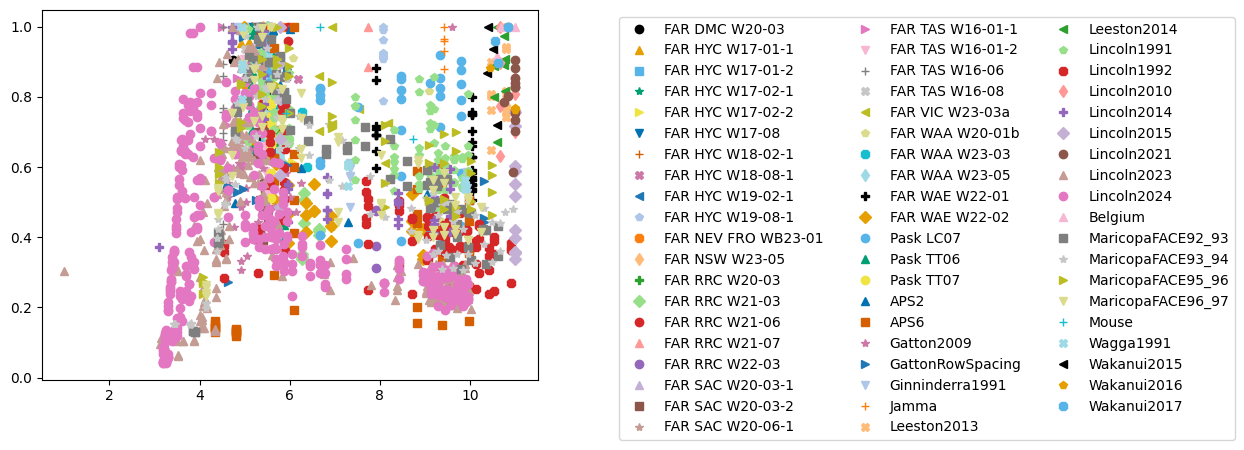

In [36]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(0).drop_duplicates()
    spos = 0
    for s in sims:
        maxSN = exData.loc[s,'Wheat.Leaf.StemPopulation'].max()
        if spos == 0:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemPopulation']/maxSN,Markers[mpos],color=Colors[cpos],label=e)
        else:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemPopulation']/maxSN,Markers[mpos],color=Colors[cpos])
        spos+=1
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

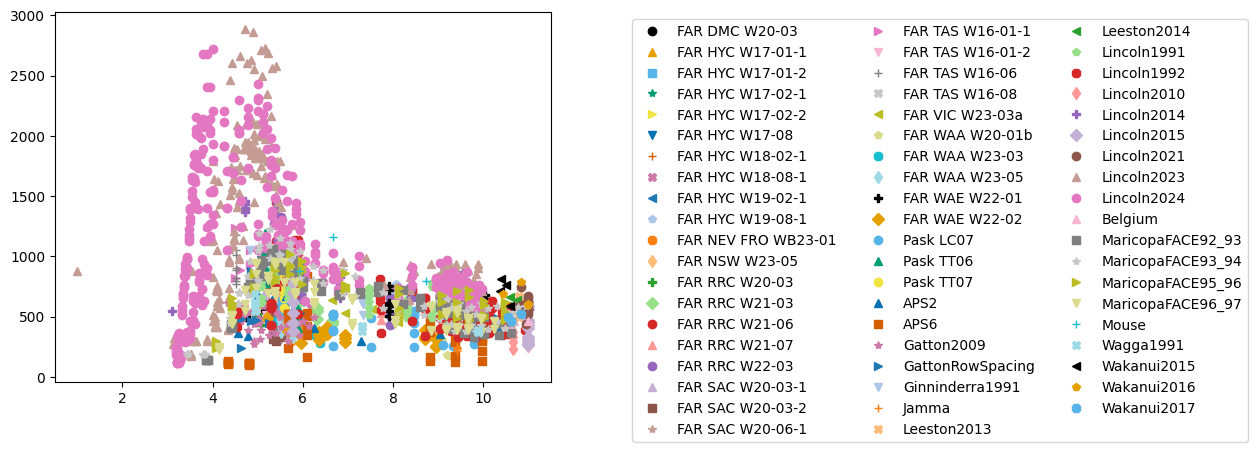

In [37]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in Experiments:
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemPopulation'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

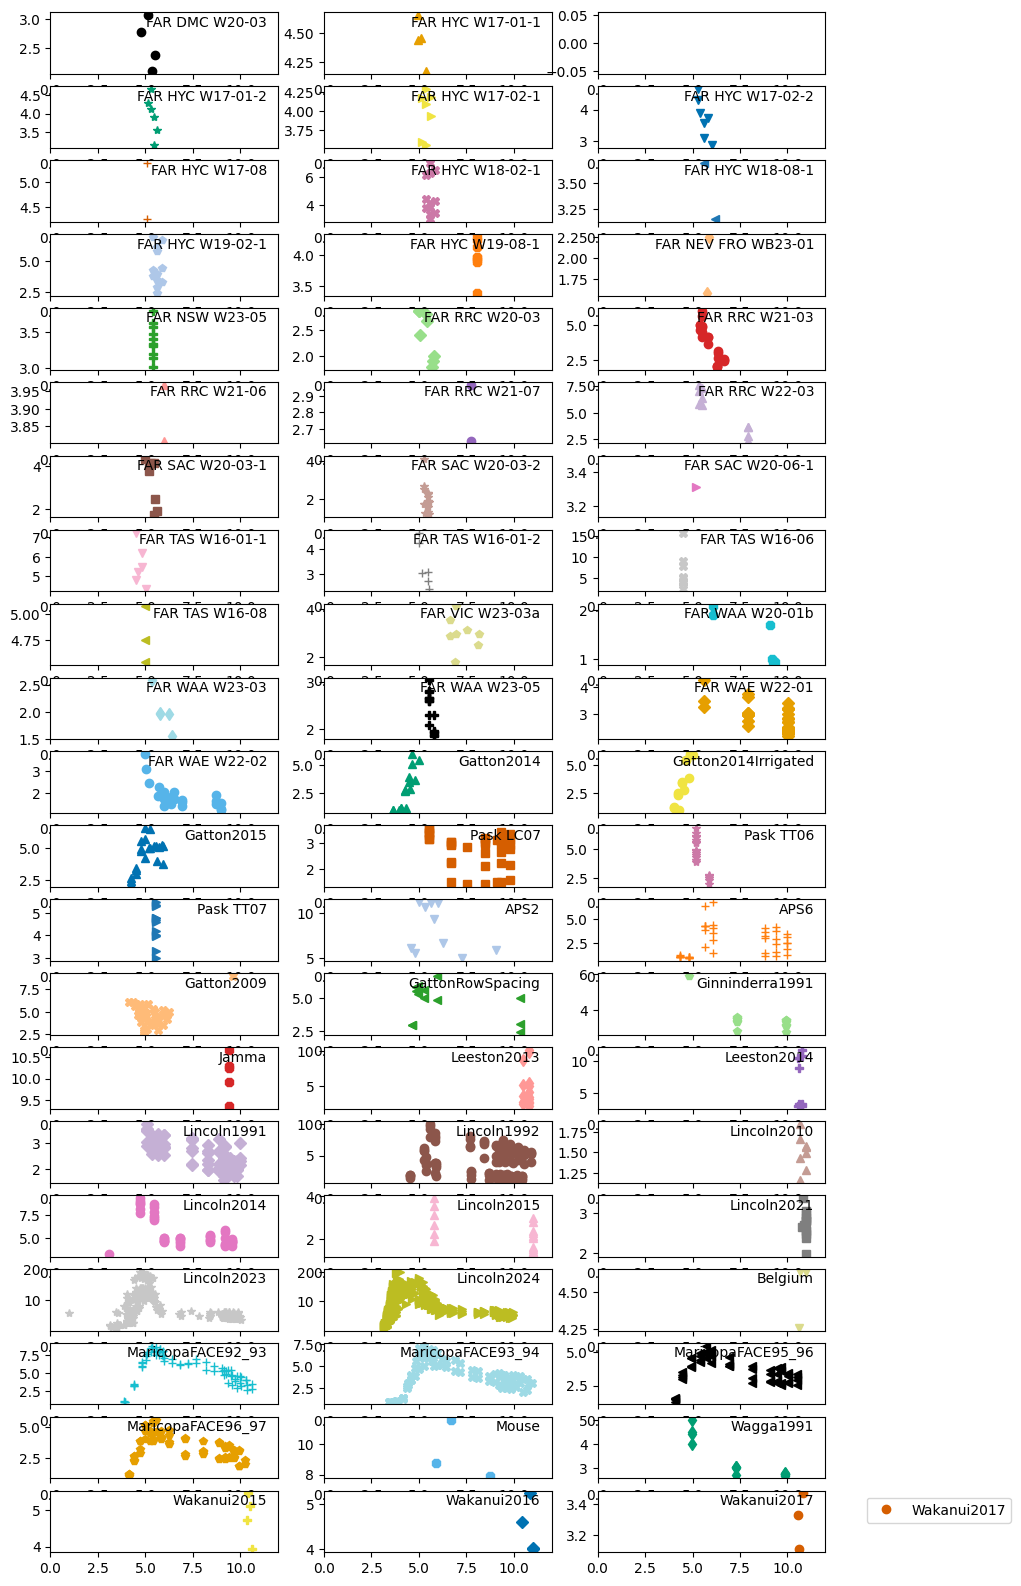

In [38]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in Experiments:
    ax = graph.add_subplot(21,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

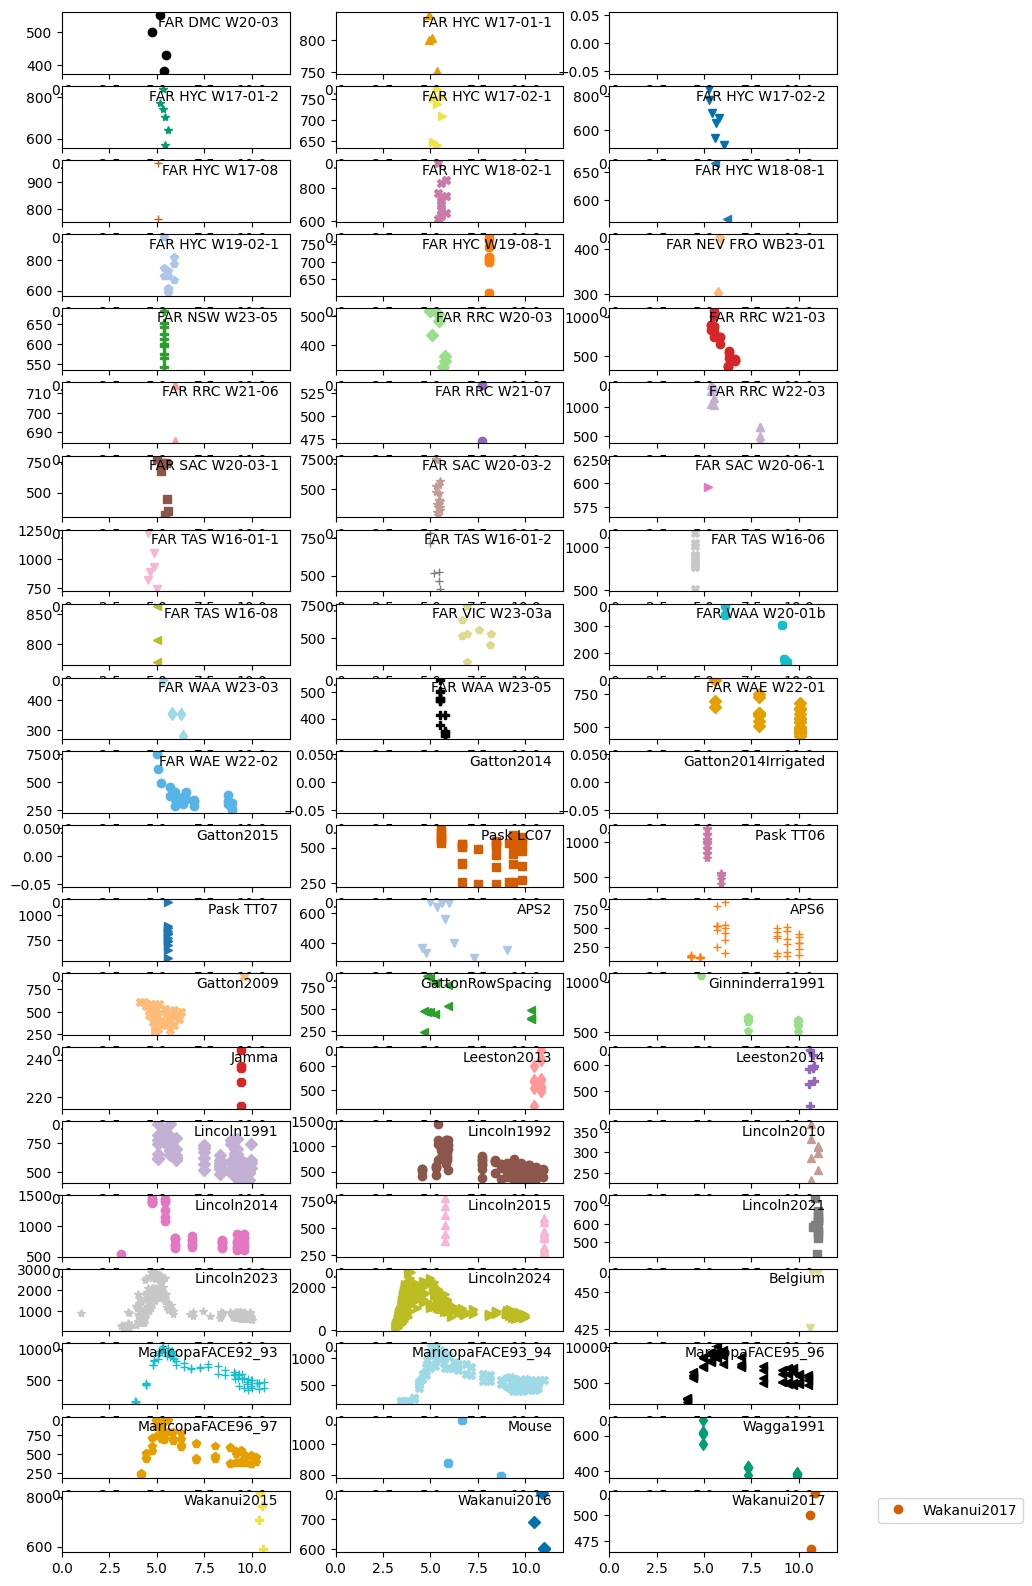

In [39]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in Experiments:
    ax = graph.add_subplot(21,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemPopulation'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

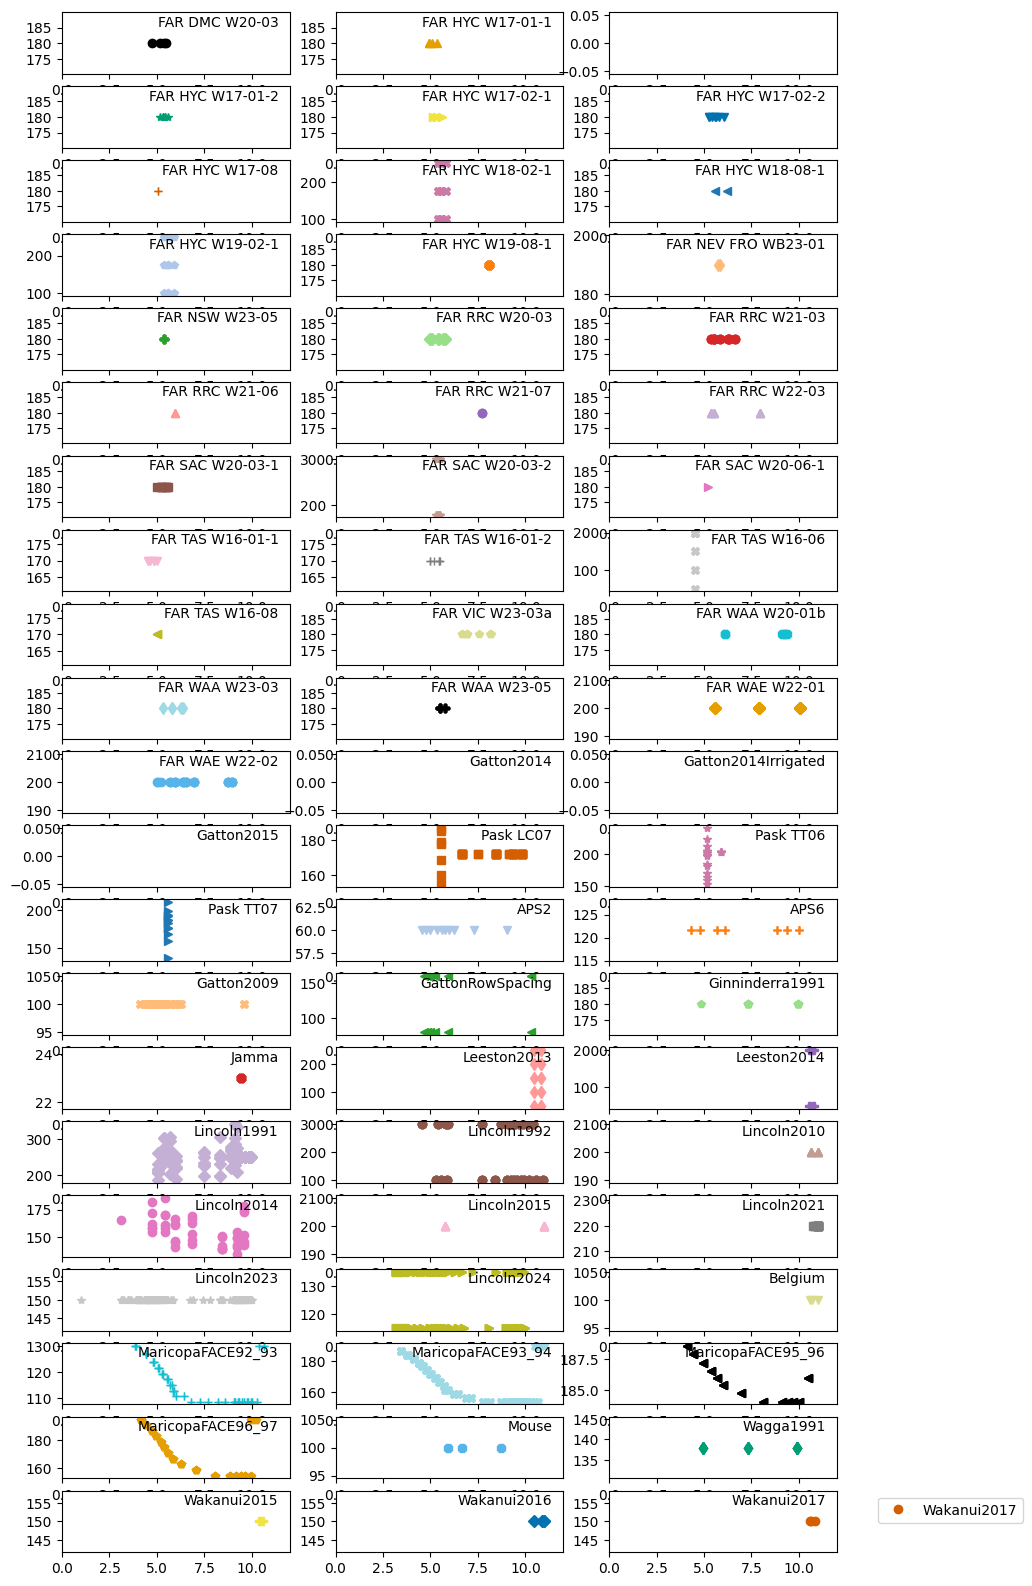

In [40]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
Experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in Experiments:
    ax = graph.add_subplot(21,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Population'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [41]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
MeanStemData = data.loc[data.loc[:,'Wheat.Phenology.Stage']>7.5,:].groupby('SimulationName').mean()
MeanStemData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemData.index]

vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']
data = Observed.loc[:,vars].dropna()
MeanStemWtData = data.loc[(data.loc[:,'Wheat.Phenology.Stage']>6.4)&(data.loc[:,'Wheat.Phenology.Stage']<9),:].groupby('SimulationName').mean()
MeanStemWtData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemWtData.index]
MeanStemData.loc[:,'Wheat.Stem.Wt'] = MeanStemWtData.reindex(MeanStemData.index).loc[:,'Wheat.Stem.Wt']
MeanStemData.loc[:,'MeanStemWt'] = MeanStemData.loc[:,'Wheat.Stem.Wt']/MeanStemData.loc[:,'Wheat.Leaf.StemPopulation']  

Text(0.5, 0, 'Wheat.population (plants/m2)')

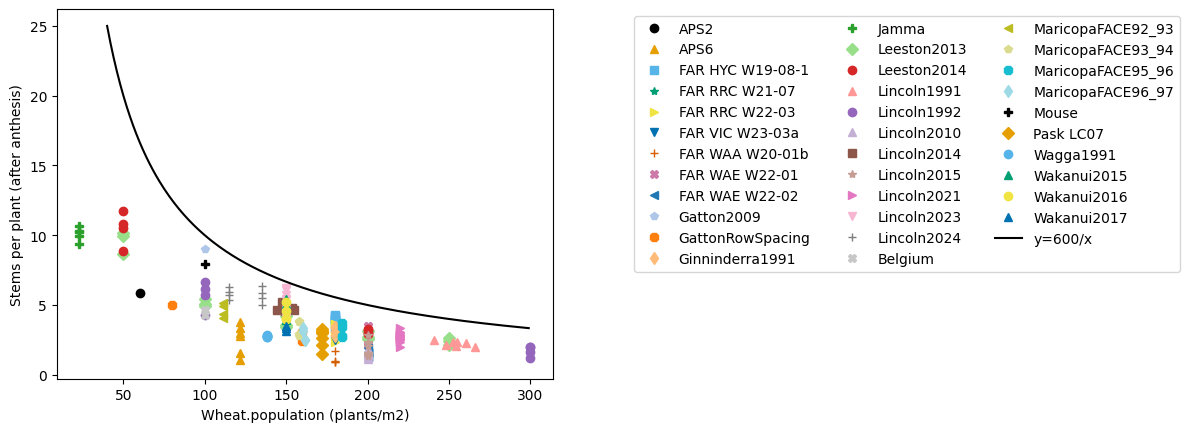

In [42]:
experiments = MeanStemData.loc[:,'Experiment'].drop_duplicates()
xvar,yvar = 'Wheat.Population', 'Wheat.Leaf.StemNumberPerPlant'
plotxy(experiments,xvar,yvar,MeanStemData)
xs = range(40,300)
ys = [1000/(x+0) for x in xs]
plt.plot(xs,ys,'-',color='k',label='y=600/x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Stems per plant (after anthesis)')
plt.xlabel('Wheat.population (plants/m2)')

(0.0, 1000.0)

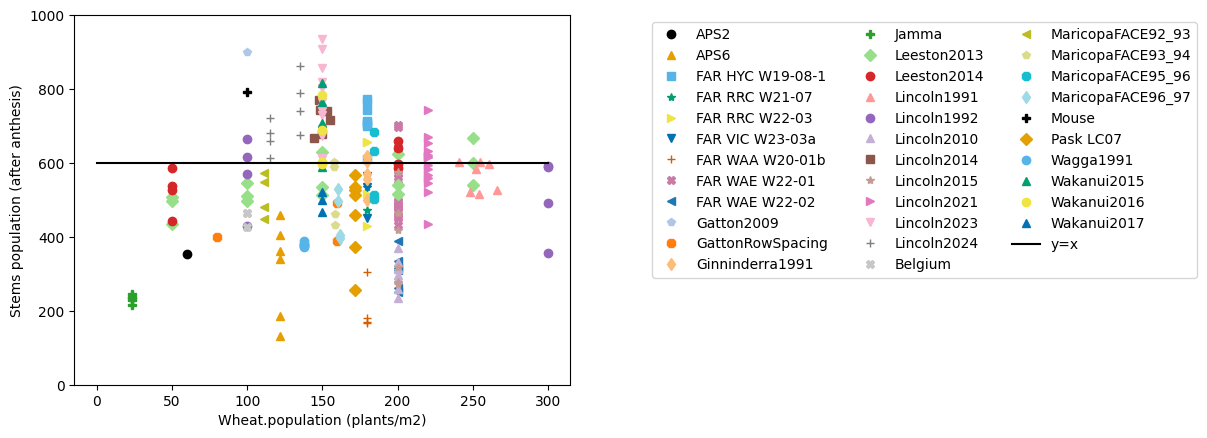

In [43]:
xvar,yvar = 'Wheat.Population', 'Wheat.Leaf.StemPopulation'
plotxy(experiments,xvar,yvar,MeanStemData)

xs = [0,300]
ys = [600,600]
plt.plot(xs,ys,'-',color='k',label='y=x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Stems population (after anthesis)')
plt.xlabel('Wheat.population (plants/m2)')
plt.ylim(0,1000)

Text(0.5, 0, 'Wheat.Stem.Wt')

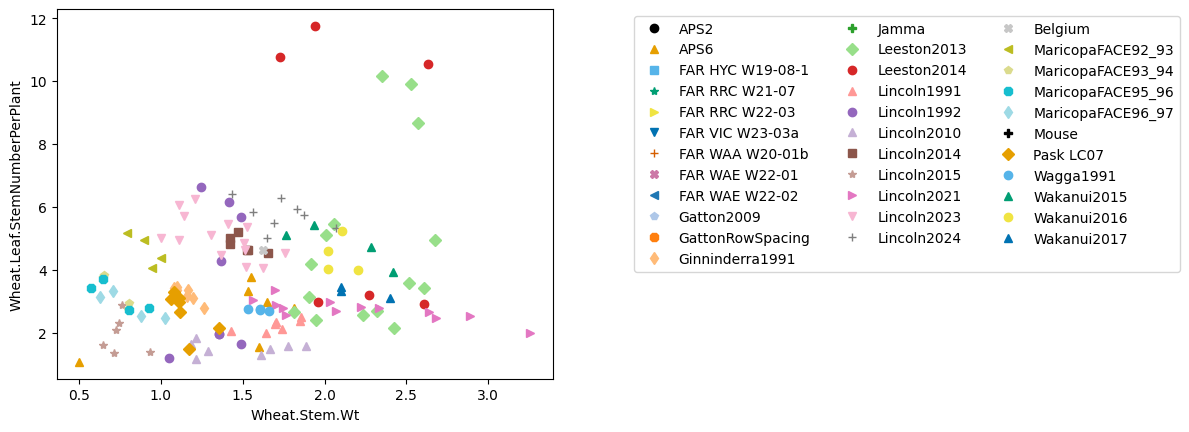

In [44]:
Experiments = list(MeanStemData.loc[:,'Experiment'].drop_duplicates())
cpos=1
mpos=1
for e in Experiments:
    plotData = MeanStemData.loc[MeanStemData.Experiment==e,:]
    plt.plot(plotData.loc[:,'MeanStemWt'],plotData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
        
# xs = [0,300]
# ys = [600,600]
# plt.plot(xs,ys,'-',color='k',label='y=x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Wheat.Leaf.StemNumberPerPlant')
plt.xlabel('Wheat.Stem.Wt')
#plt.ylim(0,1000)

In [45]:
detailedStemData = ['APS2',
 'APS6',
 'Gatton2014',
 'Gatton2015',
 'Gatton2014Irrigated',
 'GattonRowSpacing',
 'Lincoln1992',
 'Lincoln2014',
 'Lincoln2023',
 'Lincoln2024',
 'MaricopaFACE92_93',
 'MaricopaFACE93_94',
 'MaricopaFACE95_96',
 'MaricopaFACE96_97']

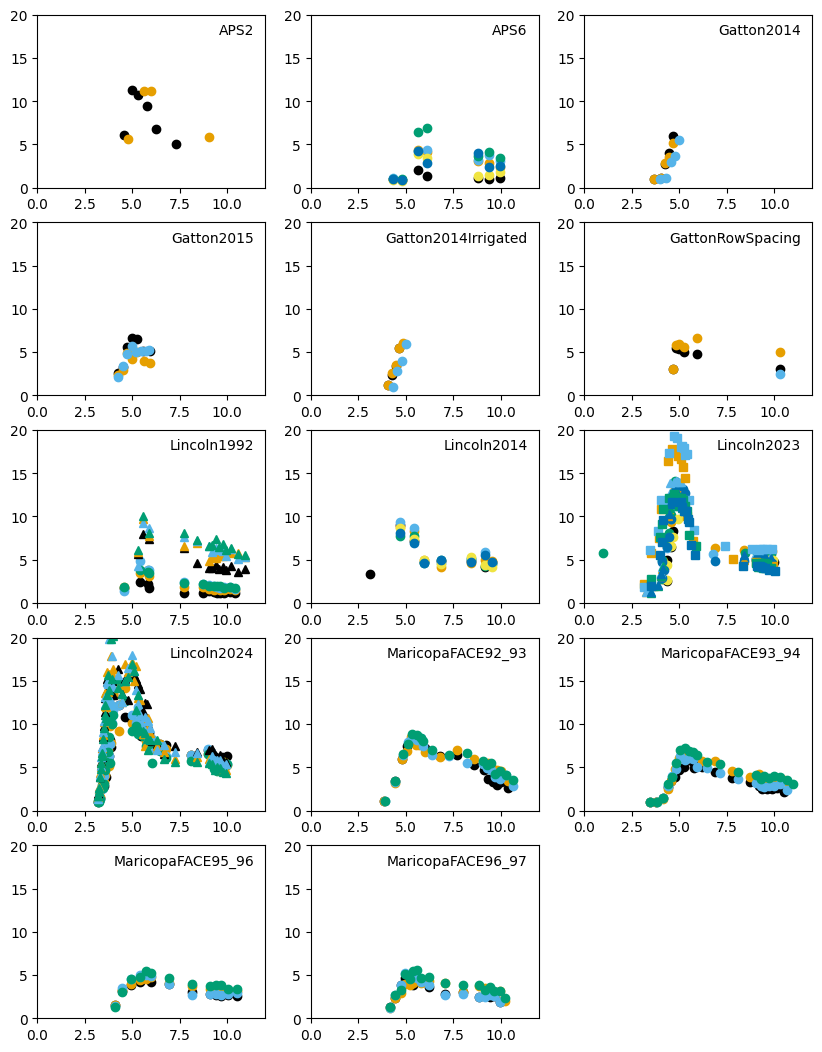

In [46]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)
    plt.ylim(0,20)

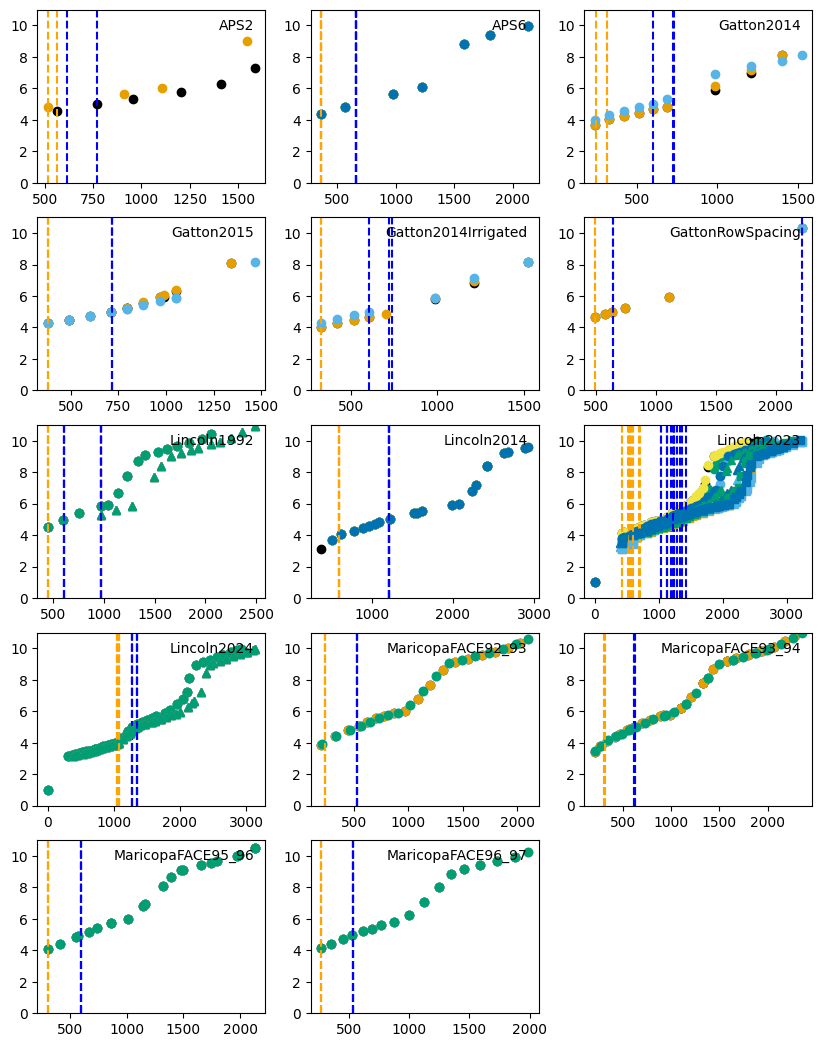

In [47]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax1 = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.AccumulatedTT'],exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],smar,color=scol,label=e)
        x = exData.loc[(slice(None),s),['Wheat.Phenology.Stage']].values.flatten()
        y = exData.loc[(slice(None),s),['Wheat.Phenology.AccumulatedTT']].values.flatten()
        vs = np.interp([4], x, y)[0]
        ts = np.interp([5], x, y)[0]
        plt.plot([vs,vs],[0,30],'--',color='orange')
        plt.plot([ts,ts],[0,30],'--',color='blue')
    plt.text(0.95,0.95,e,transform = ax1.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.ylim(0,11)
    pos+=1

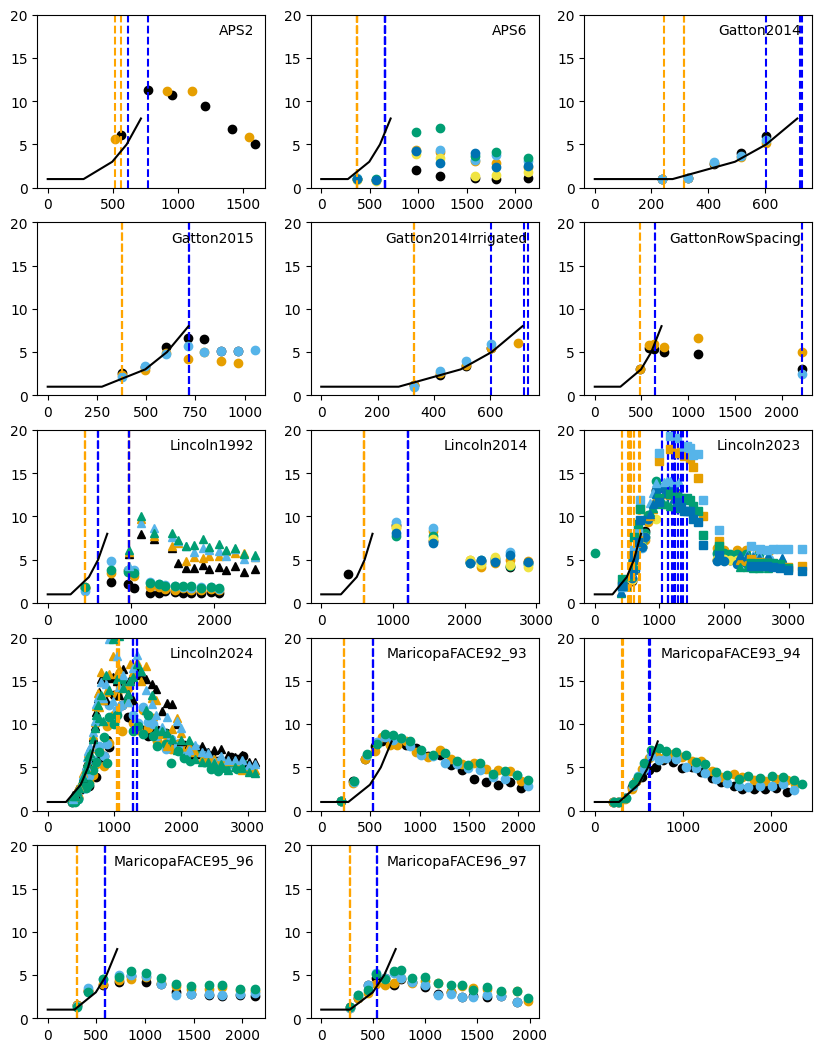

In [48]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
Phyllochron = 110
for e in detailedStemData:
    ax1 = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.AccumulatedTT'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
        x = exData.loc[(slice(None),s),['Wheat.Phenology.Stage']].values.flatten()
        y = exData.loc[(slice(None),s),['Wheat.Phenology.AccumulatedTT']].values.flatten()
        vs = np.interp([4], x, y)[0]
        ts = np.interp([5], x, y)[0]
        plt.plot([vs,vs],[0,30],'--',color='orange')
        plt.plot([ts,ts],[0,30],'--',color='blue')
    plt.plot(np.multiply([0,2.5,3.5,4.5,5.5,6.5],Phyllochron),[1,1,2,3,5,8],'-',color='k')    
    plt.text(0.95,0.95,e,transform = ax1.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.ylim(0,20)
    pos+=1

In [49]:
detailedStemAndCoverData = [
 'GattonRowSpacing',
 'Lincoln1992',
 'Lincoln2014',
 'Lincoln2023',
 'Lincoln2024']

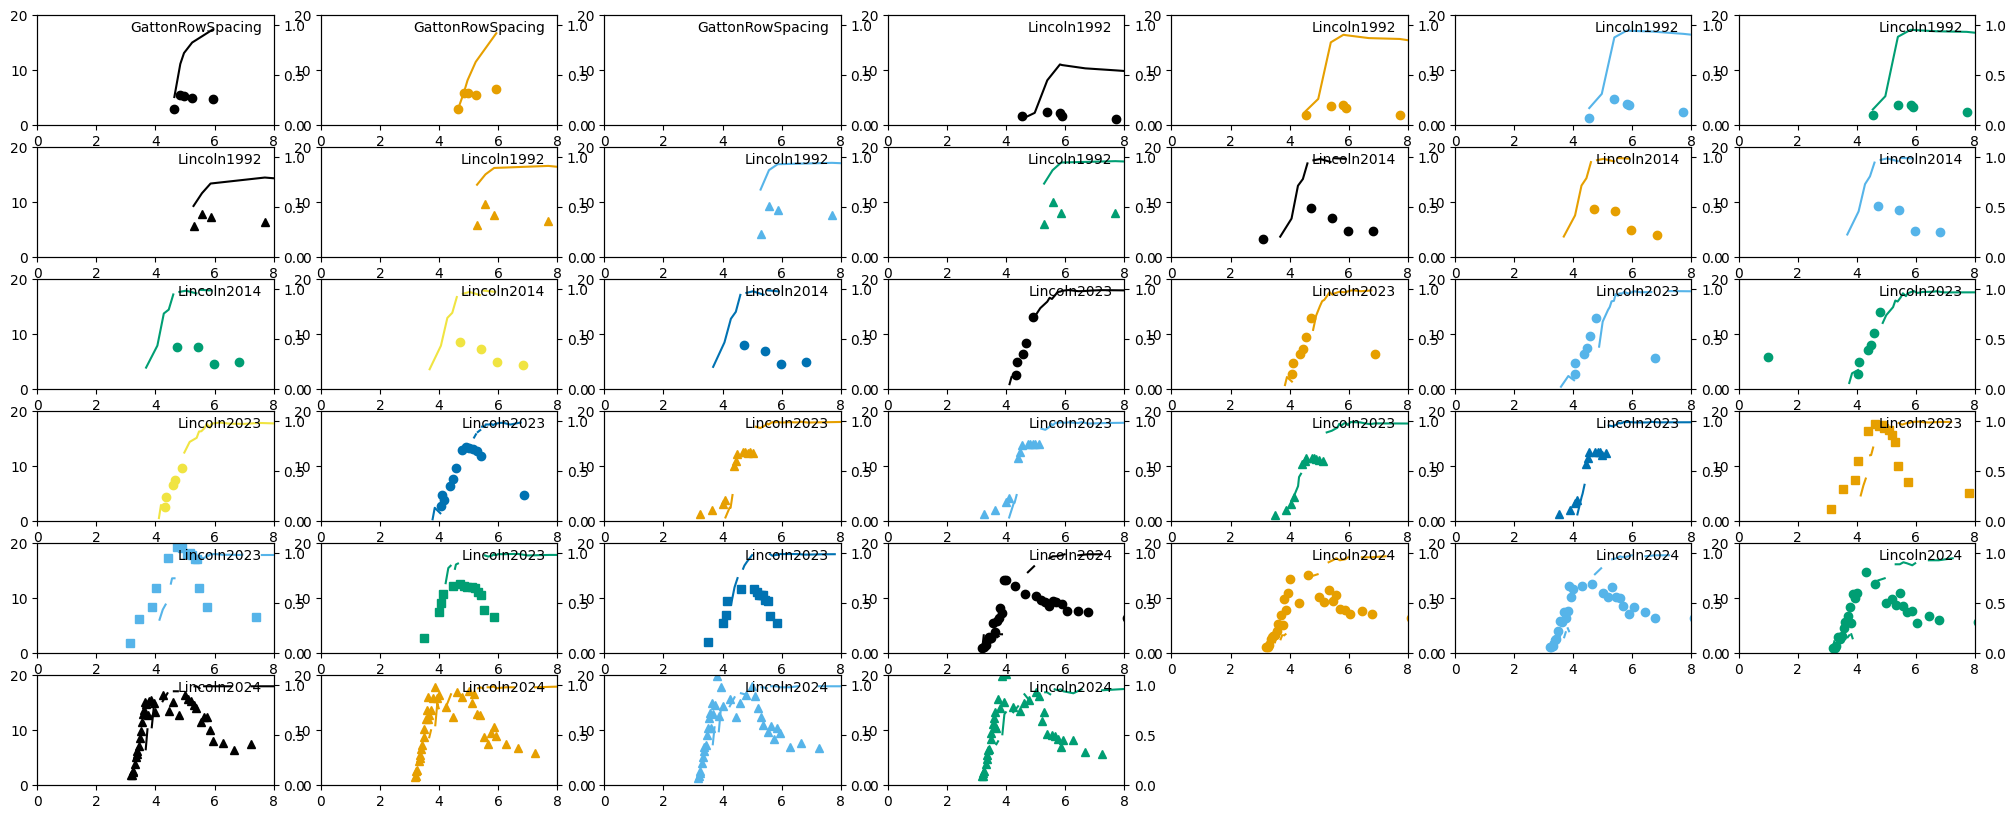

In [50]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(25,10))
for e in detailedStemAndCoverData:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    for s in sims:
        ax1 = graph.add_subplot(6,7,pos)
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
        plt.ylim(0,20)
        ax2 = ax1.twinx()
        plt.xlim(0,8)
        plt.ylim(0,1.1)
        col = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.CoverTotal'],'-',color=col,label=e)
        plt.text(0.95,0.95,e,transform = ax2.transAxes,horizontalalignment='right', verticalalignment='top')
        pos+=1

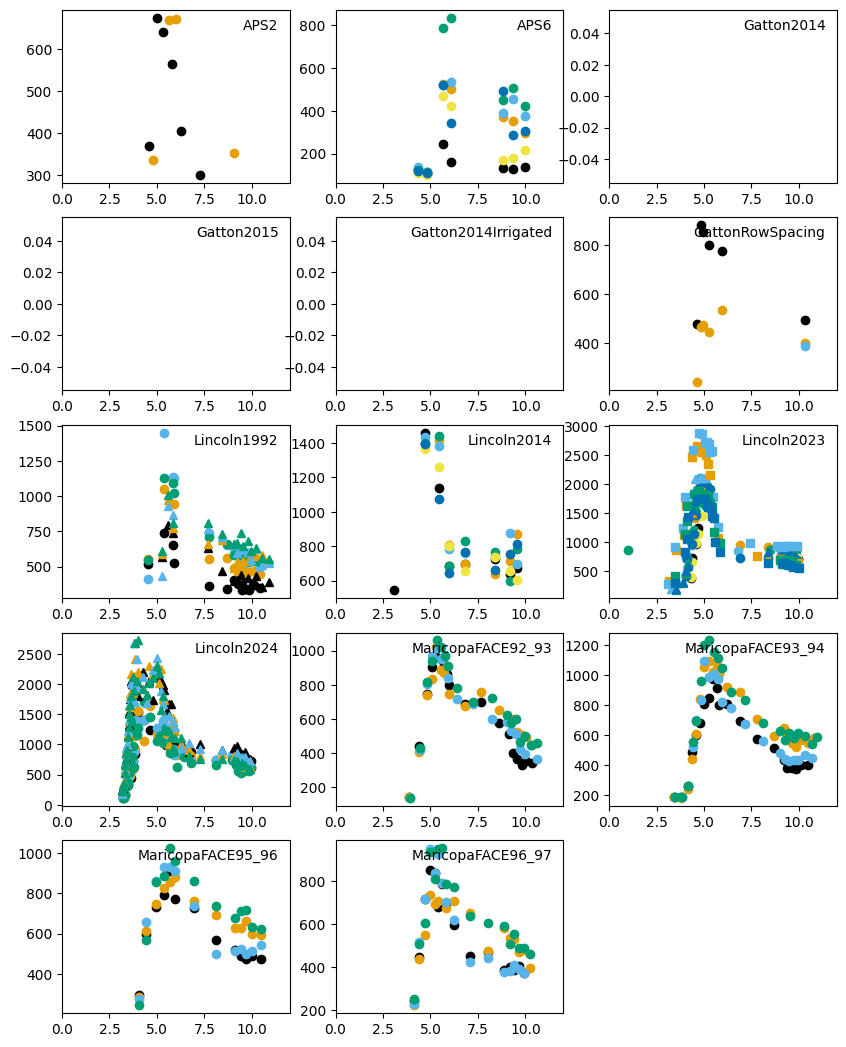

In [51]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemPopulation'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)

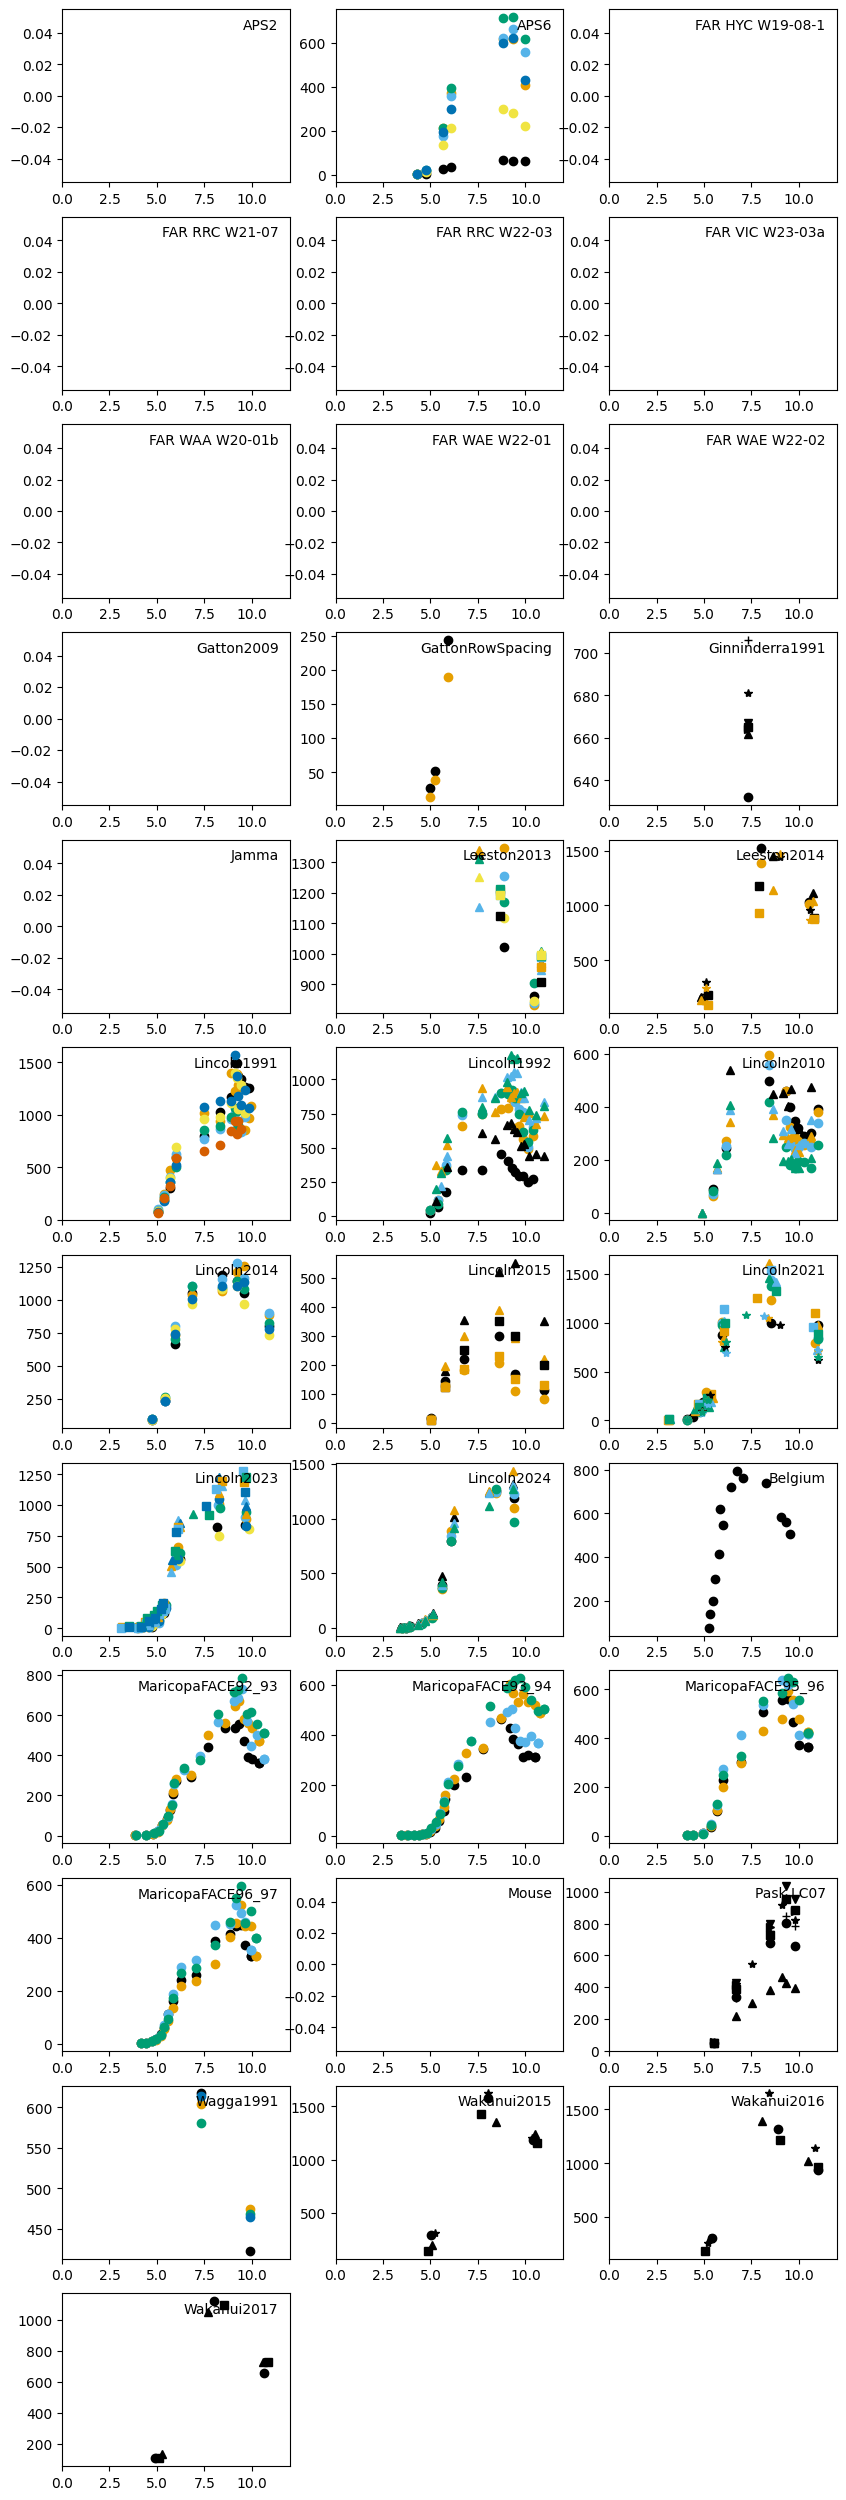

In [52]:
vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna(how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in Experiments:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Stem.Wt'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)

In [53]:
vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']
data = Observed.loc[:,vars].dropna()
MeanStemWtData = data.loc[(data.loc[:,'Wheat.Phenology.Stage']>6.4)&(data.loc[:,'Wheat.Phenology.Stage']<9),:].groupby('SimulationName').mean()
MeanStemWtData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemWtData.index]
MeanStemData.loc[:,'StemWt'] = MeanStemWtData.reindex(MeanStemData.index).loc[:,'Wheat.Stem.Wt']

# Organ Nitrogen Content

(0.0, 0.08)

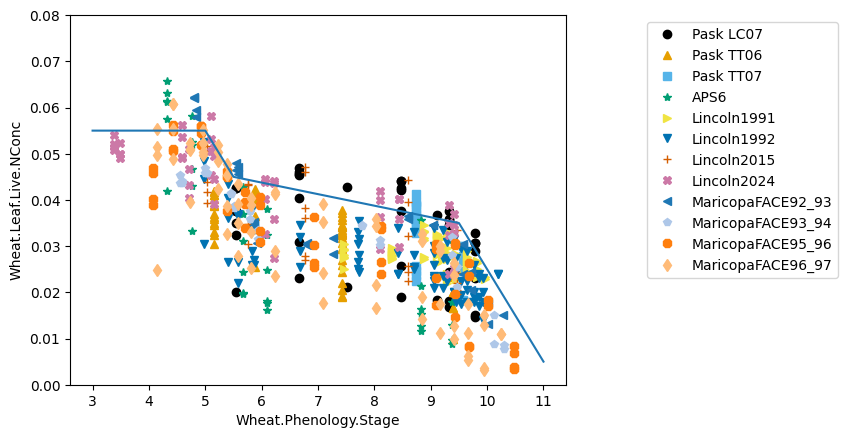

In [54]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Live.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0,5.5,9.5,11.0],
         [0.055,.055,.045,.035,.005],'-')
plt.ylim(0,.08)

(0.0, 0.08)

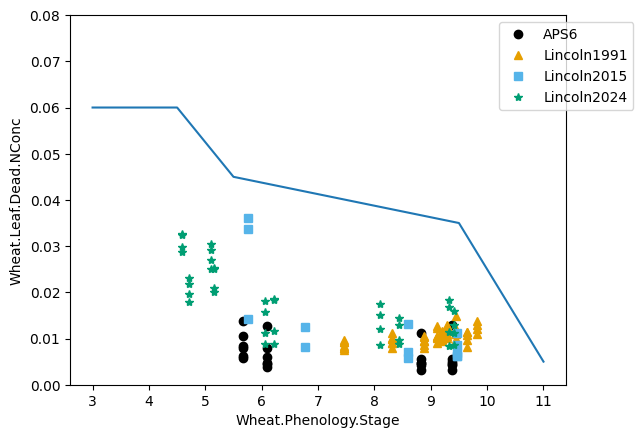

In [55]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Dead.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.5,5.5,9.5,11.0],
         [0.06,.06,.045,.035,.005],'-')
plt.ylim(0,.08)

(0.0, 0.08)

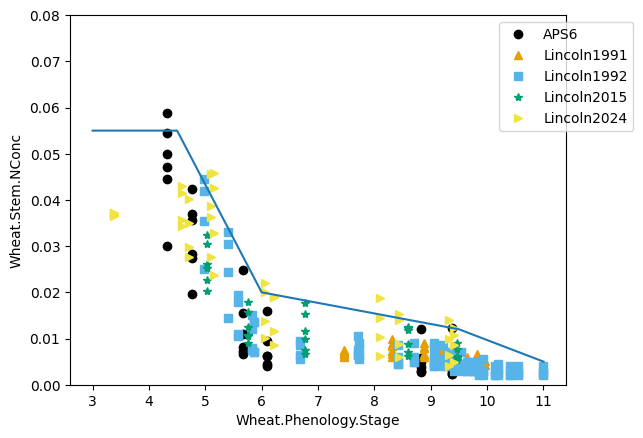

In [56]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.5,6.0,9.5,11.0],
         [0.055,.055,.02,.012,.005],'-')
plt.ylim(0,.08)

(0.0, 0.08)

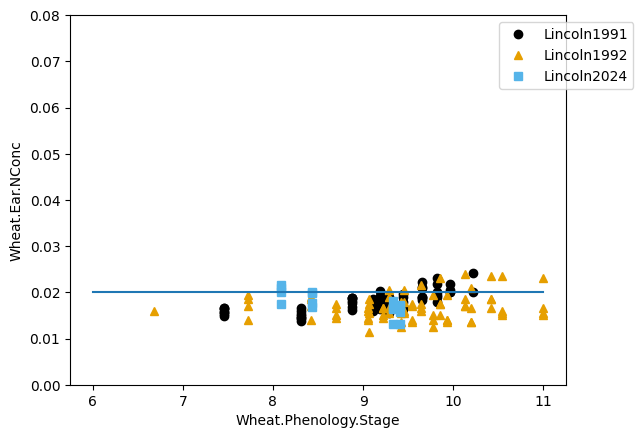

In [57]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Ear.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([6.0,11.0],
         [0.02,.02],'-')
plt.ylim(0,.08)

(0.0, 0.03)

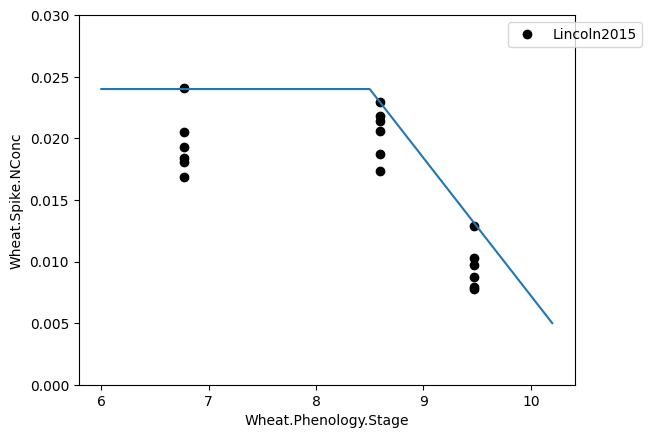

In [58]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Spike.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([6.0,8.5,10.2],
         [0.024,.024,.005],'-')
plt.ylim(0,.03)

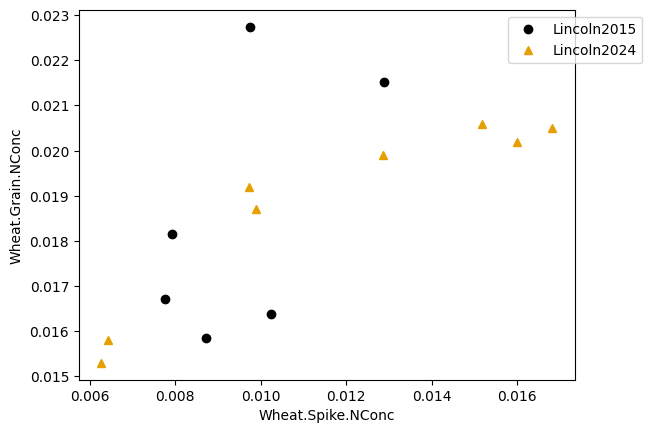

In [59]:
xvar,yvar = 'Wheat.Spike.NConc','Wheat.Grain.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
# plt.plot([3.0,4.5,5.5,9.5,11.0],
#          [0.06,.06,.045,.035,.005],'-')
#plt.ylim(0,.08)

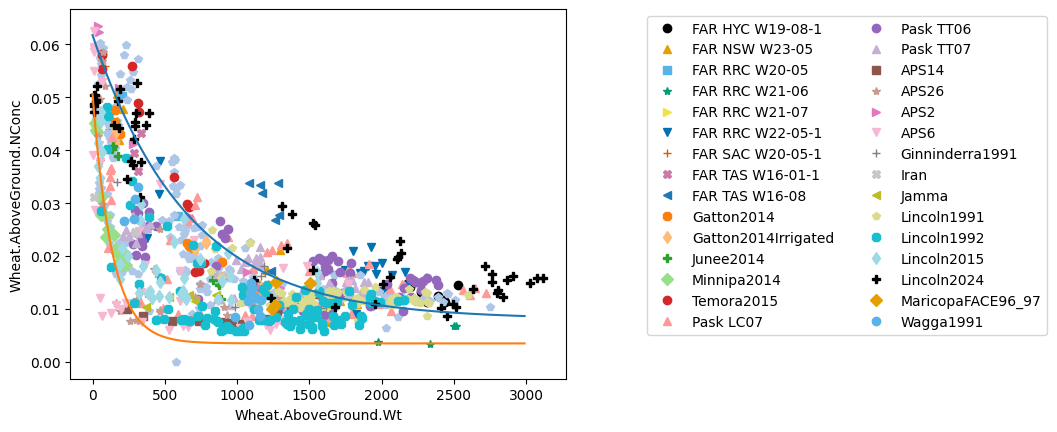

In [68]:
Observed.loc[:,'Wheat.AboveGround.NConc'] = pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.N'])/pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.Wt'])
xvar,yvar = 'Wheat.AboveGround.Wt','Wheat.AboveGround.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
def funct(b1,b2,b3,x):
    return b1 + np.exp(b2+(b3*x))
xs = range(0,3000,10)
ys = [funct(0.81,1.68,-0.00152,x)/100 for x in xs]                       
plt.plot(xs,ys,'-')
ys = [funct(0.35,1.55,-0.00738,x)/100 for x in xs]                       
plt.plot(xs,ys,'-')

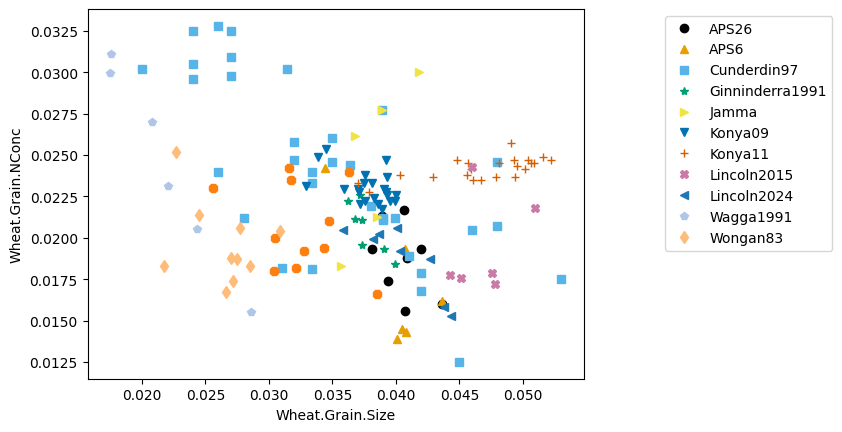

In [60]:
xvar,yvar = 'Wheat.Grain.Size','Wheat.Grain.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [61]:
def plotxySizeScaled(experiments,xvar,yvar,data,sizeVar,sizeScaler,addLeg = True,ncols=np.nan):
    cpos=1
    mpos=1
    for e in experiments:
        plotData = data.loc[data.Experiment==e,:]
        xdata = pd.to_numeric(plotData.loc[:,xvar])
        ydata = pd.to_numeric(plotData.loc[:,yvar])
        sizeVal = pd.to_numeric(plotData.loc[:,sizeVar])/sizeScaler
        for s in xdata.index:
            label = e if s == xdata.index[0] else None
            plt.plot(xdata[s],ydata[s],Markers[mpos],color=Colors[cpos], ms=sizeVal[s],label=label)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    if addLeg == True:
        if np.isnan(ncols):
             ncols = np.ceil(experiments.size/17)
        plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
    plt.ylabel(yvar)
    plt.xlabel(xvar)

In [62]:
def Value_at_stage(df, variable, target, tol_low, tol_high):

    # Filter stage window
    window = df.loc[
        (df["Wheat.Phenology.Stage"] > tol_low) &
        (df["Wheat.Phenology.Stage"] < tol_high)
    ].copy()

    window = window[window[variable].notna()]

    if window.empty:
        return pd.DataFrame(columns=[variable])

    # Distance to target stage
    window["stage_dist"] = (window["Wheat.Phenology.Stage"] - target).abs()

    # Choose closest per simulation
    out = (
        window
        .sort_values("stage_dist")
        .loc[~window.index.droplevel(-1).duplicated()]
        .loc[:, [variable, "Experiment"]]
        .droplevel(-1)  # drop Clock.Today
    )

    return out

In [63]:
Observed.loc[:,'Wheat.Phenology.PTQ']

File        SimulationName                Clock.Today        
Dookie2024  DookieEVA2024SowApril_BigRed  2024-04-27 00:00:00    2.719798
                                          2024-05-24 00:00:00    2.181022
                                          2024-05-31 00:00:00    1.686597
                                          2024-06-03 00:00:00    1.494631
                                          2024-06-14 00:00:00    0.868717
                                                                   ...   
Wheat       Yucheng04                     2005-06-07 00:00:00    2.120686
                                          2005-06-08 00:00:00    1.674736
                                          2005-06-11 00:00:00    1.521825
                                          2005-06-17 00:00:00    0.000000
                                          2005-06-22 00:00:00    0.000000
Name: Wheat.Phenology.PTQ, Length: 33455, dtype: float64

In [64]:
AnthesisStemWt = Value_at_stage(Observed, 'Wheat.Stem.Wt', 8, 6.5, 8.5)
AnthesisStemWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisStemWt.index:
    AnthesisStemWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisStemWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)
AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt'] = AnthesisStemWt.loc[:,'Wheat.Stem.Wt'] * 1.4 #  Based on analysis above, spike wt = 0.4 * stem wt at anthesis
AnthesisStemWt.loc[:,'Wheat.GrainPerGramOfStemPlusSpike'] =  AnthesisStemWt.loc[:,'Wheat.Grain.Number']/AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt']
AnthesisStemWt = AnthesisStemWt.groupby(level=[0, 1]).first()
#Add PTQ mean into data table
MetVar = 'Wheat.Phenology.PTQ'
for sim in AnthesisStemWt.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        AnthesisStemWt.loc[sim,MetVar+"Critical"] = metVarMean
    except:
        do = 'nothing'
for sim in AnthesisStemWt.index:
    #try:
    metData = Observed.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
    stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
    metVarMean = metData.loc[stageFilter,MetVar].mean()
    AnthesisStemWt.loc[sim,MetVar+"CriticalMean"] = metVarMean
    # except:
    #     do = 'nothing'
AnthesisStemWt.loc[:,'Stem/PTQ'] = AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt']/AnthesisStemWt.loc[:,'Wheat.Phenology.PTQCritical']
AnthesisStemWt.loc[:,'PotGNStemWt'] = AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt'] * 24
AnthesisStemWt.loc[:,'PotGNPTQ'] = -16153 + AnthesisStemWt.loc[:,'Wheat.Phenology.PTQCritical'] * 13461
AnthesisStemWt.loc[:,'PotGN'] = np.minimum(AnthesisStemWt.loc[:,'PotGNStemWt'],AnthesisStemWt.loc[:,'PotGNPTQ'])

C:\Users\Cflhxb\AppData\Local\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Cflhxb\AppData\Local\anaconda3\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [65]:
AnthesisStemWt

Wheat.Stem.Wt      Experiment  \
File       SimulationName                                                     
Dookie2024 DookieEVA2024SowApril_Illabo          537.813301   DookieEVA2024   
           DookieEVA2024SowApril_UOM001_3_47     583.535256   DookieEVA2024   
           DookieEVA2024SowMay_UOM001_3_47       409.572762   DookieEVA2024   
           DookieEVA2024SowMay_UOM001_9_1        551.761306   DookieEVA2024   
           DookieWWHI2024CvIllaboSow17-Apr       553.477674  DookieWWHI2024   
...                                                     ...             ...   
Wheat      Wakanui2015Sow20-MarCmNormal         1620.653297     Wakanui2015   
           Wakanui2016Sow14-AprCmNormal         1395.069645     Wakanui2016   
           Wakanui2016Sow29-MarCmNormal         1648.898828     Wakanui2016   
           Wakanui2017Sow09-MarCmNormal         1119.612385     Wakanui2017   
           Wakanui2017Sow19-AprCmNormal         1048.104100     Wakanui2017   

                                              Wheat.Grain.Number  \
File       SimulationName                                          
Dookie2024 DookieEVA2024SowApril_Illabo             11717.491854   
           DookieEVA2024SowApril_UOM001_3_47        17964.896618   
           DookieEVA2024SowMay_UOM001_3_47          13478.159722   
           DookieEVA2024SowMay_UOM001_9_1           15257.677336   
           DookieWWHI2024CvIllaboSow17-Apr          13485.631890   
...                                                          ...   
Wheat      Wakanui2015Sow20-MarCmNormal             34015.054280   
           Wakanui2016Sow14-AprCmNormal             31633.869070   
           Wakanui2016Sow29-MarCmNormal             30650.416580   
           Wakanui2017Sow09-MarCmNormal             24417.591800   
           Wakanui2017Sow19-AprCmNormal             27975.955410   

                                              Wheat.Grain.Wt  \
File       SimulationName                                      
Dookie2024 DookieEVA2024SowApril_Illabo           454.080000   
           DookieEVA2024SowApril_UOM001_3_47      722.730000   
           DookieEVA2024SowMay_UOM001_3_47        581.710000   
           DookieEVA2024SowMay_UOM001_9_1         608.045000   
           DookieWWHI2024CvIllaboSow17-Apr        537.410000   
...                                                      ...   
Wheat      Wakanui2015Sow20-MarCmNormal          1416.668350   
           Wakanui2016Sow14-AprCmNormal          1288.426567   
           Wakanui2016Sow29-MarCmNormal          1213.563467   
           Wakanui2017Sow09-MarCmNormal          1075.947400   
           Wakanui2017Sow19-AprCmNormal          1189.375765   

                                              Wheat.StemPlusSpikeWt  \
File       SimulationName                                             
Dookie2024 DookieEVA2024SowApril_Illabo                  752.938621   
           DookieEVA2024SowApril_UOM001_3_47             816.949358   
           DookieEVA2024SowMay_UOM001_3_47               573.401867   
           DookieEVA2024SowMay_UOM001_9_1                772.465829   
           DookieWWHI2024CvIllaboSow17-Apr               774.868743   
...                                                             ...   
Wheat      Wakanui2015Sow20-MarCmNormal                 2268.914616   
           Wakanui2016Sow14-AprCmNormal                 1953.097503   
           Wakanui2016Sow29-MarCmNormal                 2308.458359   
           Wakanui2017Sow09-MarCmNormal                 1567.457339   
           Wakanui2017Sow19-AprCmNormal                 1467.345740   

                                              Wheat.GrainPerGramOfStemPlusSpike  \
File       SimulationName                                                         
Dookie2024 DookieEVA2024SowApril_Illabo                               15.562347   
           DookieEVA2024SowApril_UOM001_3_47                          21.990221   
           DookieEVA2024SowMay_UOM001_3_47  

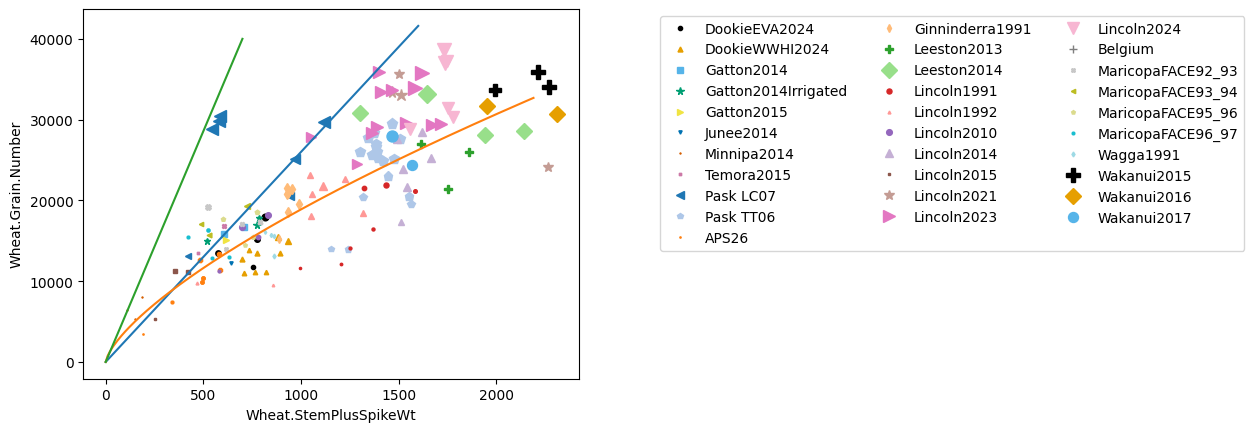

In [66]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.StemPlusSpikeWt','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
plt.plot(xs,[pow(150,x,0.7) for x in xs],'-')
plt.plot([0,700],[0,40000],'-')

In [67]:
b = 35000/(3.8-1.2)
a = 1.2 * -b

In [68]:
b

13461.538461538463

In [69]:
a

-16153.846153846154

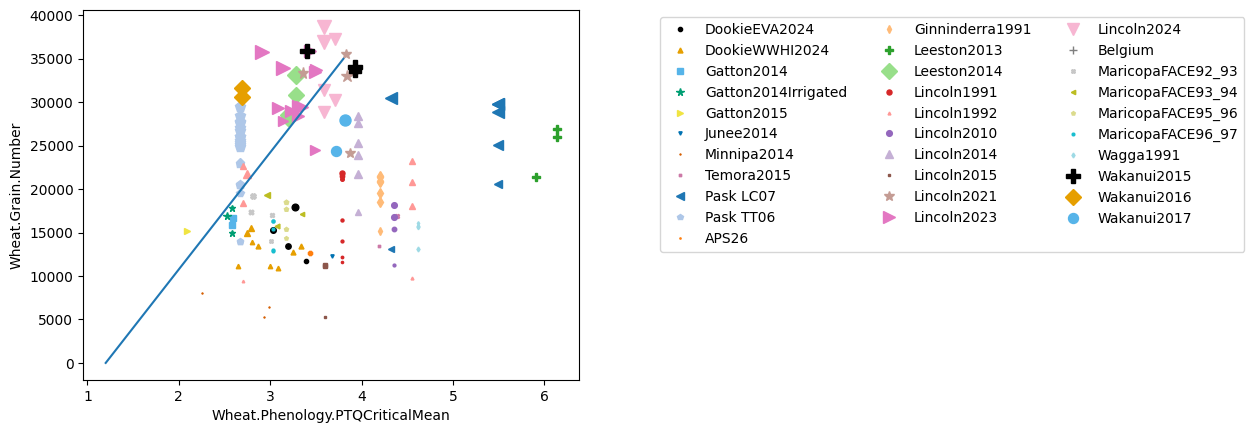

In [70]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Phenology.PTQCriticalMean','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
plt.plot([1.2,3.8],[0,35000],'-')
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
#plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
#plt.plot(xs,[pow(100,x,0.7) for x in xs],'-')

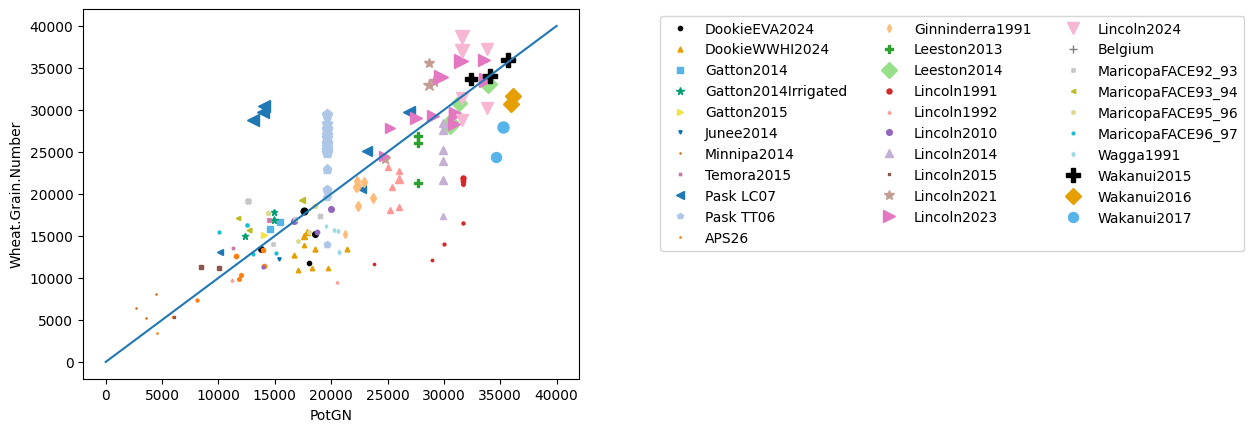

In [71]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'PotGN','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
plt.plot([0,40000],[0,40000],'-')
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
#plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
#plt.plot(xs,[pow(100,x,0.7) for x in xs],'-')

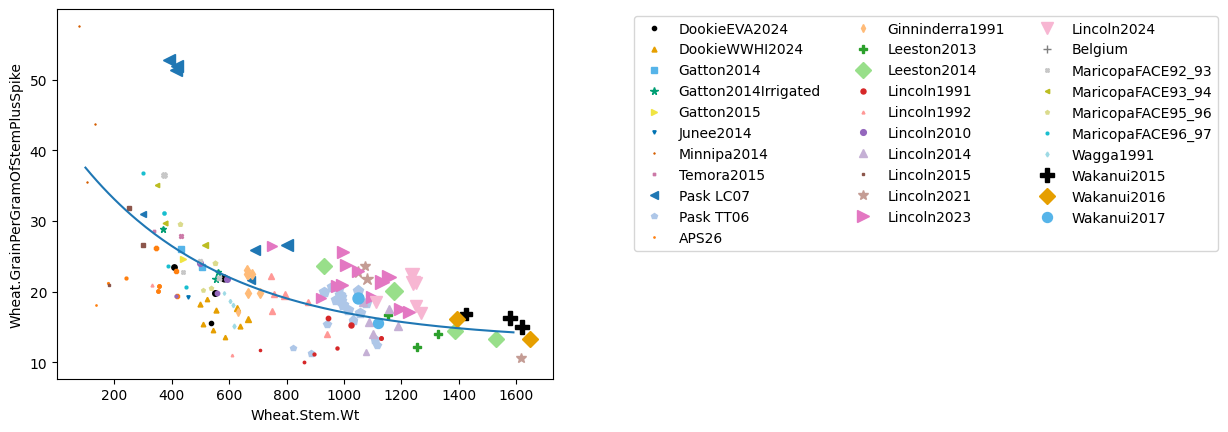

In [72]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Stem.Wt','Wheat.GrainPerGramOfStemPlusSpike',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
xs = range(100,1600,10)
def expon(x, a, b, c):
    return a + b * np.exp(c*x)
plt.plot(xs,[expon(x,13,30,-.002) for x in xs],'-')

In [73]:
AnthesisLeafWt = Value_at_stage(Observed, 'Wheat.Leaf.Live.Wt', 8, 6.5, 8.5)
AnthesisLeafWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisLeafWt.index:
    AnthesisLeafWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisLeafWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)

C:\Users\Cflhxb\AppData\Local\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Cflhxb\AppData\Local\anaconda3\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


TypeError: cannot convert the series to <class 'float'>

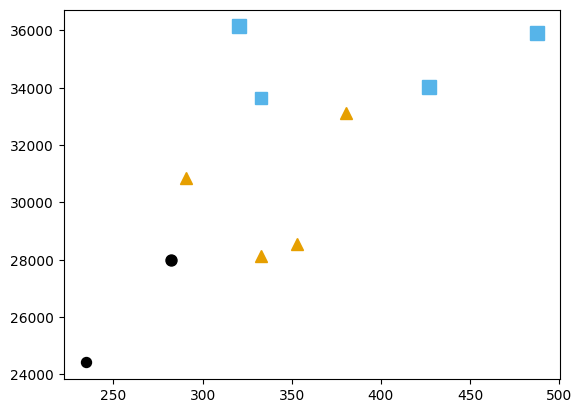

In [74]:
experiments = AnthesisLeafWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Leaf.Live.Wt','Wheat.Grain.Number',AnthesisLeafWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,500]
plt.plot(xs,np.multiply(xs,130),'-')
plt.plot(xs,np.multiply(xs,100),'-')
plt.plot(xs,np.multiply(xs,70),'-')

In [ ]:
AnthesisTotalWt = Value_at_stage(Observed, 'Wheat.AboveGround.Wt', 8, 6.5, 8.5)
AnthesisTotalWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisTotalWt.index:
    AnthesisTotalWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisTotalWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)

In [ ]:
experiments = AnthesisTotalWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.AboveGround.Wt','Wheat.Grain.Number',AnthesisTotalWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,2500]
plt.plot(xs,np.multiply(xs,25),'-')
plt.plot(xs,np.multiply(xs,15),'-')
plt.plot(xs,np.multiply(xs,10),'-')

In [ ]:
AnthesisSpikeWt = Value_at_stage(Observed, 'Wheat.Spike.Wt', 8, 6.5, 8.5)
AnthesisSpikeWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisSpikeWt.index:
    AnthesisSpikeWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisSpikeWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)

In [ ]:
experiments = AnthesisSpikeWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Spike.Wt','Wheat.Grain.Number',AnthesisSpikeWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,300]
plt.plot(xs,np.multiply(xs,90),'-')
plt.plot(xs,np.multiply(xs,60),'-')
plt.plot(xs,np.multiply(xs,30),'-')

In [ ]:
gwts = range(100,1800,300)
gns = range(1000,41000,1000)
for gwt in gwts:
    gss = []
    for gn in gns:
        maxGS = 0.06 - 0.00000055*gn
        y = min(maxGS,gwt/gn)
        gss.append(y)
    plt.plot(gns,gss,"-",color='grey')
xvar,yvar = 'Wheat.Grain.Number','Wheat.Grain.Size'
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
experiments = Observed.loc[harvFilter,:].dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxySizeScaled(experiments,xvar,yvar,Observed.loc[harvFilter,:],'Wheat.Grain.Wt',150,ncols=3)
#plt.plot([500,16000,40000],[0.052,0.052,0.04],"-")

plt.ylim(0,0.06)

In [ ]:
Observed.loc[:,'Wheat.Stem.WtPerGrain'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.Grain.Number']
xvar,yvar = 'Wheat.Stem.WtPerGrain','Wheat.Grain.Size'
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
experiments = Observed.loc[harvFilter,:].dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[harvFilter,:])
#plt.plot([500,16000,40000],[0.052,0.052,0.04],"-")

In [ ]:
Observed.loc[:,'Wheat.Spike.WtPerGrain'] = Observed.loc[:,'Wheat.Spike.Wt']/Observed.loc[:,'Wheat.Grain.Number']
xvar,yvar = 'Wheat.Spike.WtPerGrain','Wheat.Grain.Size'
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
experiments = Observed.loc[harvFilter,:].dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[harvFilter,:])
#plt.plot([500,16000,40000],[0.052,0.052,0.04],"-")

In [ ]:
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
HarvVar = 'Wheat.Grain.Number'
MetVar = 'Wheat.Phenology.PTQ'
startStage = 6
endStage = 8
HarvestData = pd.DataFrame(Observed.loc[harvFilter,[HarvVar,'Wheat.Grain.Wt','Experiment']].dropna())
for sim in HarvestData.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        #simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        #harVarValue = HarvestData.loc[sim,HarvVar]
        HarvestData.loc[sim,MetVar+"Cricital"] = metVarMean,
        #plt.plot(metVarMean, harVarValue,'o',ms = simYield/200)
    except:
        do = 'nothing'
#plt.plot(HarvestData.loc[:,MetVar],HarvestData.loc[:,HarvVar],'o')
experiments = HarvestData.dropna(subset=[MetVar+"Cricital",HarvVar]).Experiment.drop_duplicates()
plotxySizeScaled(experiments,MetVar+"Cricital",HarvVar,HarvestData,'Wheat.Grain.Wt',150,ncols=3)
plt.plot([1.2,3.8],[0,40000],'-')

In [ ]:
MetVar = 'Wheat.Phenology.PTQ'
for sim in AnthesisStemWt.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        #simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        #harVarValue = HarvestData.loc[sim,HarvVar]
        AnthesisStemWt.loc[sim,MetVar+"Cricital"] = metVarMean,
        #plt.plot(metVarMean, harVarValue,'o',ms = simYield/200)
    except:
        do = 'nothing'

In [ ]:
AnthesisStemWt

In [ ]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.StemPlusSpikeWt','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
plt.plot(xs,[pow(150,x,0.7) for x in xs],'-')

In [ ]:
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
HarvVar = 'Wheat.Grain.Size'
MetVar = 'IWeather.Radn'#'Wheat.Phenology.PTQ'
startStage = 4
endStage = 9
HarvestData = pd.DataFrame(Observed.loc[harvFilter,[HarvVar,'Wheat.Grain.Wt']].dropna())
for sim in HarvestData.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        harVarValue = HarvestData.loc[sim,HarvVar]
        #HarvestData.loc[sim,MetVar] = VarMean,
        plt.plot(metVarMean, harVarValue,'o',ms = simYield/200)
    except:
        do = 'nothing'
#plt.plot(HarvestData.loc[:,MetVar],HarvestData.loc[:,HarvVar],'o')
#plt.plot([1.2,4],[0,40000],'-')

In [ ]:
gwts = range(100,1800,300)
gns = range(1000,41000,1000)
for gwt in gwts:
    gss = []
    for gn in gns:
        maxGS = 0.06 - 0.00000055*gn
        y = min(maxGS,gwt/gn)
        gss.append(y)
    plt.plot(gns,gss,"-")
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
HarvVar = 'Wheat.Grain.Size'
MetVar = 'IWeather.Radn'#'Wheat.Phenology.PTQ'
startStage = 4
endStage = 9
HarvestData = pd.DataFrame(Observed.loc[harvFilter,['Wheat.Grain.Number','Wheat.Grain.Size','Wheat.Grain.Wt']].dropna())
for sim in HarvestData.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        y = HarvestData.loc[sim,'Wheat.Grain.Size']
        simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        x = HarvestData.loc[sim,'Wheat.Grain.Number']
        #HarvestData.loc[sim,MetVar] = VarMean,
        plt.plot(x, y,'o',ms = simYield/150)
    except:
        do = 'nothing'
#plt.plot(HarvestData.loc[:,MetVar],HarvestData.loc[:,HarvVar],'o')
#plt.plot([1.2,4],[0,40000],'-')

In [ ]:
GrainNData = Observed.loc[:,['Wheat.Grain.Wt','Wheat.Grain.NConc','Wheat.Grain.N','Wheat.Phenology.Stage','Experiment']].dropna().copy()
GrainNExperiments = GrainNData.Experiment.drop_duplicates()
GrainNExpGraphs = plt.figure(figsize=(20,10))
pos=1
for e in GrainNExperiments:
    ax = GrainNExpGraphs.add_subplot(4,6,pos)
    ExpGrainNData = GrainNData.loc[GrainNData.Experiment==e].droplevel(0)
    sims = ExpGrainNData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpGrainNData.loc[s,'Wheat.Grain.NConc'])
        x = pd.to_numeric(ExpGrainNData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Extinction Coefficient

In [ ]:
kgraph = plt.figure(figsize=(10,5))
cpos = 1
mpos = 1
expts = Observed.index.get_level_values(0).drop_duplicates()
for e in Experiments:
    expData = Observed.loc[Observed.Experiment==e,:].droplevel(0)
    sims = expData.index.get_level_values(0).drop_duplicates()
    expDF = pd.DataFrame()
    for s in sims:
        left = expData.loc[s, ['Wheat.Leaf.CoverTotal']].dropna().copy()
        right = expData.loc[s, ['Wheat.Leaf.LAI','Wheat.Phenology.Stage']].dropna().copy()
        left.index = pd.to_datetime(left.index)
        right.index = pd.to_datetime(right.index)
        if ((left.index.size>0) and (right.index.size>0)):
            left = left.sort_index()
            right = right.sort_index()
            df = pd.merge_asof(
                left, right,
                left_index=True,
                right_index=True,
                direction="nearest",
                tolerance=pd.Timedelta("3D")
            )
            df["K"] = -np.log(1.0 - df["Wheat.Leaf.CoverTotal"]) / df["Wheat.Leaf.LAI"]  
            expDF = pd.concat([expDF,df])
            #df = df.loc[df['Wheat.Leaf.CoverTotal']>.2,:]
    if (expDF.index.size>0):
        plt.plot(expDF.loc[:,'Wheat.Phenology.Stage'],expDF.loc[:,'K'],Markers[mpos],color=Colors[cpos],label=e)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
plt.ylim(0,1.1)
plt.xlim(3,7)
plt.legend(bbox_to_anchor=(.5, .7),numpoints=1,ncols=2)
plt.ylabel('K')
plt.xlabel('Wheat.Phenology.Stage')
plt.plot([4,4.8,5.2,6],[0.75,0.75,0.55,0.55],'-')

In [ ]:
SLAData = Observed.loc[:,['Wheat.Leaf.SpecificAreaCanopy','Wheat.Phenology.Stage','Experiment']].dropna().copy()
SLAExperiments = SLAData.Experiment.drop_duplicates()
SLAExpGraphs = plt.figure(figsize=(20,10))
pos=1
for e in SLAExperiments:
    ax = SLAExpGraphs.add_subplot(4,6,pos)
    ExpSLAData = SLAData.loc[SLAData.Experiment==e].droplevel(0)
    sims = ExpSLAData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Leaf.SpecificAreaCanopy'])
        x = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Above Ground N

In [ ]:
AGNExperiments = ['APS2',
 'APS26',
 'APS6',
 'FAR NSW W23-05',
 'FAR RRC W22-05-1',
 'Ginninderra1991',
 'Lincoln1991',
 'Lincoln1992',
 'Lincoln2015',
 'Lincoln2024',
 'MaricopaFACE96_97',
 'Pask LC07',
 'Pask TT06',
 'Pask TT07',
 'Wagga1991']

Observed.loc[:,'Wheat.AboveGround.N'] = pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.N'] )
AGNData = Observed.loc[:,['Wheat.AboveGround.N','Wheat.Phenology.Stage','Experiment']].dropna().copy()
#AGNExperiments = AGNData.Experiment.drop_duplicates()
AGNGraphs = plt.figure(figsize=(10,20))
pos=1
Nexpts = []
for e in AGNExperiments:
    ax = AGNGraphs.add_subplot(8,3,pos)
    ExpAGNData = AGNData.loc[AGNData.Experiment==e].droplevel(0)
    ExpAGNData.drop_duplicates(inplace=True)
    sims = ExpAGNData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        if ExpAGNData.loc[s,'Wheat.AboveGround.N'].count() > 2:
            Nexpts.append(e)
        simMaxAGN = ExpAGNData.loc[s,'Wheat.AboveGround.N'].max()
        ExpAGNData.loc[s,'RelativeNUptake'] = (ExpAGNData.loc[s,'Wheat.AboveGround.N']/simMaxAGN).values
        y = ExpAGNData.loc[s,'RelativeNUptake']
        x = ExpAGNData.loc[s,'Wheat.Phenology.Stage']
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar+'--',color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.plot([8,8],[0,1.5],'--',color='orange')
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,1.05)
    plt.xlim(3,12)
    if pos in [1,4,7,10,13]:
        plt.ylabel('Relative AboveGround.N')
    if pos in [13,14,15]:
        plt.xlabel('Wheat.Phenology.Stage')
    #plt.legend(fontsize=7)
    pos+=1   
AGNGraphs.savefig('RelativeNUptake.png')

In [ ]:
simulations = list(Observed.index.get_level_values(1).drop_duplicates())

In [ ]:
for sim in simulations:
    try:
        plt.plot(max(Observed.loc[(slice(None),sim),"Wheat.AboveGround.Wt"].dropna().values),
             max(Observed.loc[(slice(None),sim),"Wheat.Stem.WtProportion"].dropna().values),'o')
    except:
        do='Nothing'

In [ ]:
Observed.loc[:,"Wheat.Phenology.Stage"] > 5.5 

In [ ]:
Observed